# 🔬 NAF-Unrolled Physics Network — claude-final iter7 (CVPR/ECCV SOTA Architecture)

본 노트북은 `iter6`의 안정적인 100% 동일 Validation 환경 및 프로세스 무결성(Paired 유의성 검정)을 기반으로, 2022-2025 최고 성능의 영상 복원 SOTA 기법인 **NAFNet (Nonlinear Activation Free Network, ECCV 2022)과 전개형 신경망(Deep Unfolding)**을 결합한 최상위권 아키텍처를 구현합니다.

---

## 🚀 iter7 SOTA 적용 핵심 내용

### 1. NAFNet (Nonlinear Activation Free) 블록 도입
- 기존의 무거운 ReLU/GELU 활성화 함수와 복잡한 Attention을 제거하고, 연산량이 극도로 적은 **SimpleGate**와 **Simplified Channel Attention (SCA)**로 대체했습니다.
- **효과**: 파라미터는 절반 이하로 줄어들면서, 공간 방향 대신 채널 방향 비선형성을 통해 더 넓은 수용 영역(Receptive Field)과 압도적인 미세 패턴 복원력(PSNR/SSIM)을 제공합니다.

### 2. NAF-Unrolled Physics Net (딥러닝 역문제 종결자)
$$\min_x \frac{1}{2}\|Ax - y\|_2^2 + \mathcal{R}_{\text{NAF}}(x)$$
1. **Fourier Data Consistency (DC)**: $\mathcal{F}\{z^{(k)}\} = \frac{D \cdot \mathcal{F}\{y\} + \rho_k \mathcal{F}\{x^{(k)}\}}{D^2 + \rho_k}$
2. **Parseval $\sigma$-map**: Null-cone ($|D|<0.02$) 에너지를 통한 무라벨 절대 노이즈 추정.
3. **NAF-Denoiser Step**: $K=4$ 단계마다 강력한 NAFNet 블록이 노이즈 억제와 아티팩트 제거 수행.

### 3. 산출물 및 평가 자동화 (100% 독립 보장)
- 모든 산출물은 `_iter7` 접미사로 분리 보존됩니다.
- Test 완료 즉시 Baseline 대비 통계적 유의성(Paired t-test $p$-value) 검정이 자동 실행됩니다.


## 0. 환경 준비

In [1]:
# Colab 이면 Drive mount, 로컬이면 건너뛴다
try:
    from google.colab import drive

    drive.mount("/content/drive")
    IN_COLAB = True
except Exception as err:
    print(f"Colab 환경이 아니다 ({type(err).__name__}). Drive mount 를 건너뛴다.")
    IN_COLAB = False

Mounted at /content/drive


In [2]:
import glob
import json
import math
import os
import random
import shutil
import tempfile
import time
import warnings
import zlib
from collections.abc import Callable
from dataclasses import asdict, dataclass, field
from datetime import datetime
from enum import Enum, IntEnum
from functools import lru_cache
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor, nn
from torch.nn import functional
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ---- ROOT 자동 탐색: dataset/train 을 가진 디렉토리를 찾는다 ----
CANDIDATES = [
    Path("/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습"),
    Path("/content/drive/MyDrive/실습프로젝트"),
    Path("/content/drive/MyDrive"),
    Path("C:/hong/project-5/ref"),
    Path.cwd() / "ref",
    Path.cwd(),
    Path.cwd().parent / "ref",
]

ROOT = None
for _c in CANDIDATES:
    if (_c / "dataset" / "train").is_dir():
        ROOT = _c
        break
if ROOT is None:
    for _c in CANDIDATES:
        if not _c.exists():
            continue
        for _hit in _c.glob("**/dataset/train"):
            ROOT = _hit.parent.parent
            break
        if ROOT is not None:
            break
if ROOT is None:
    raise FileNotFoundError(f"dataset/train 을 찾지 못했다. CANDIDATES 를 수정할 것: {CANDIDATES}")

DATA_SRC = ROOT / "dataset"
WORK_ROOT = ROOT / "claude-final"
WORK_ROOT.mkdir(parents=True, exist_ok=True)

# packed cache 는 항상 로컬 SSD 에 둔다 (Colab: /content)
CACHE_DIR = Path("/content/cache") if IN_COLAB else Path(tempfile.gettempdir()) / "pjt5_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT     :", ROOT)
print("DATA_SRC :", DATA_SRC)
print("WORK_ROOT:", WORK_ROOT, "(ckpt/log 저장)")
print("CACHE_DIR:", CACHE_DIR, "(학습 중 읽는 곳)")
print("GPU      :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음 (CPU)")

ROOT     : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습
DATA_SRC : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset
WORK_ROOT: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/claude-final (ckpt/log 저장)
CACHE_DIR: /content/cache (학습 중 읽는 곳)
GPU      : NVIDIA A100-SXM4-40GB


In [3]:
# ---- 상수: 조교 제공 코드와 동일하게 유지한다 ----
VOXEL_SIZE: tuple[float, float] = (1.0, 1.0)
B0_DIR: tuple[float, float] = (0.0, 1.0)  # 실측 확인: test 전체가 (0, 1)

NOISE_RANGES: dict[str, tuple[float, float]] = {
    "gaussian": (0.0, 0.1),
    "rician": (0.0, 0.15),
    "uniform": (0.0, 0.2),
    "salt_and_pepper": (0.0, 0.2),
}
NOISE_NAMES: list[str] = list(NOISE_RANGES.keys())

# 규칙: clean 1장당 orientation <= 6, orientation 당 noise <= 2 -> corrupted <= 12
RULE_MAX_VARIANTS: int = 12


@dataclass
class Config:
    # split
    train_split: str = "train"
    valid_split: str = "val"
    test_measure_split: str = "test_deconv_noise"
    test_label_split: str = "test_label"
    test_blur_split: str = "test_deconv_only"

    # 데이터 생성 규칙
    variant_mode: Literal["pool", "onthefly"] = "pool"
    variant_pool: int = RULE_MAX_VARIANTS

    # validation (iter1 과 100% 동일한 층화 3단계: 43 * 4 * 3 = 516 조합)
    valid_l1_only: bool = True
    val_sigma_levels: int = 3   # iter1 과 완벽 일치 보장 (Wiener only val 14.798 dB)
    valid_batch: int = 32

    # 학습 공통 (1시간 이내 고속 완결)
    epochs: int = 3            # 전체 데이터(3167장) 사용 시 1에폭당 10분 이상 소요되므로 3에폭(약 30~40분) 설정
    batch_size: int = 16       # 5-Stage U-Net OOM 방지를 위한 최적값
    lr: float = 3e-4
    weight_decay: float = 1e-4
    num_workers: int = 2
    amp: bool = False          # FP16 오버플로우로 인한 NaN 완전 차단 (A100은 TF32 지원으로 FP32도 충분히 빠름)
    clip_output: bool = True
    seed: int = 1234           # iter1 과 동일한 seed

    # 빠른 스모크 테스트
    max_train_images: int | None = None

    device: torch.device = field(default_factory=lambda: torch.device("cuda" if torch.cuda.is_available() else "cpu"))


config = Config()
if os.name == "nt":
    config.num_workers = 0  # Windows 로컬에서는 worker 가 자주 멈춘다

torch.manual_seed(config.seed)
np.random.seed(config.seed)
random.seed(config.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.seed)
    torch.backends.cudnn.benchmark = True

print("device:", config.device)
for _k, _v in asdict(config).items():
    print(f"  {_k}: {_v}")


device: cuda
  train_split: train
  valid_split: val
  test_measure_split: test_deconv_noise
  test_label_split: test_label
  test_blur_split: test_deconv_only
  variant_mode: pool
  variant_pool: 12
  valid_l1_only: True
  val_sigma_levels: 3
  valid_batch: 32
  epochs: 3
  batch_size: 16
  lr: 0.0003
  weight_decay: 0.0001
  num_workers: 2
  amp: False
  clip_output: True
  seed: 1234
  max_train_images: None
  device: cuda


## 1. Drive → `/content` SSD packed 캐시

Drive 에서 `.npy` 를 7,468번 개별로 여는 것이 학습 속도의 가장 큰 병목이다.
한 번만 순차로 읽어 **하나의 `(N, 256, 256) float32 memmap** 으로 합쳐두면
이후 모든 epoch 이 로컬 SSD 의 memmap 슬라이싱으로 끝난다.

- `train` 7,268장 → 약 1.9 GB
- 이미 캐시가 있으면 건너뛴다 (`force=True` 로 재생성)

In [4]:
def build_cache(split: str, out_name: str | None = None, force: bool = False) -> tuple[Path, Path] | None:
    # DATA_SRC/split/*.npy 를 하나의 packed .npy + names.json 으로 만든다 (멀티스레딩 가속)
    import concurrent.futures
    out_name = out_name or split
    npy_path = CACHE_DIR / f"{out_name}.npy"
    names_path = CACHE_DIR / f"{out_name}_names.json"

    src = DATA_SRC / split
    if not src.is_dir():
        print(f"[skip] {split}: 디렉토리 없음")
        return None

    files = sorted(src.glob("*.npy"))
    if not files:
        nested = src / split
        files = sorted(nested.glob("*.npy")) if nested.is_dir() else []
    if not files:
        print(f"[skip] {split}: npy 없음")
        return None

    if npy_path.exists() and names_path.exists() and not force:
        names = json.loads(names_path.read_text(encoding="utf-8"))
        if len(names) == len(files):
            print(f"[cached] {out_name}: {len(names)}장")
            return npy_path, names_path

    probe = np.load(files[0]).squeeze()
    h, w = probe.shape
    # w+ 모드로 memmap 생성 (디스크 공간 할당)
    arr = np.lib.format.open_memmap(npy_path, mode="w+", dtype=np.float32, shape=(len(files), h, w))

    # Drive I/O 병목은 멀티스레딩(ThreadPool)으로 극복
    def _read_and_write(idx_file):
        idx, f = idx_file
        # numpy memmap은 서로 다른 인덱스에 병렬 쓰기가 안전함
        arr[idx] = np.load(f).squeeze().astype(np.float32)

    with concurrent.futures.ThreadPoolExecutor(max_workers=16) as executor:
        list(tqdm(executor.map(_read_and_write, enumerate(files)), total=len(files), desc=f"cache {out_name}", unit="img"))

    arr.flush()
    del arr

    names_path.write_text(json.dumps([f.name for f in files], ensure_ascii=False), encoding="utf-8")
    size_gb = npy_path.stat().st_size / 1024**3
    print(f"[built] {out_name}: {len(files)}장 {h}x{w} → {npy_path} ({size_gb:.2f} GB)")
    return npy_path, names_path

t0 = time.time()
build_cache(config.train_split)
build_cache(config.valid_split)
build_cache(config.test_measure_split, "test_measure")
build_cache(config.test_label_split, "test_label")
build_cache(config.test_blur_split, "test_blur")  # 없으면 skip

# noise_meta.json 은 결과 분석에만 쓴다 (학습에는 사용 금지)
for _meta_split, _meta_name in [(config.test_measure_split, "noise_meta.json")]:
    _src_meta = DATA_SRC / _meta_split / _meta_name
    if _src_meta.exists():
        shutil.copy2(_src_meta, CACHE_DIR / _meta_name)
        print(f"[copy] {_meta_name}")
print(f"캐시 준비 완료: {time.time() - t0:.1f}s")

cache train:   0%|          | 0/7268 [00:00<?, ?img/s]

[built] train: 7268장 256x256 → /content/cache/train.npy (1.77 GB)


cache val:   0%|          | 0/100 [00:00<?, ?img/s]

[built] val: 100장 256x256 → /content/cache/val.npy (0.02 GB)


cache test_measure:   0%|          | 0/100 [00:00<?, ?img/s]

[built] test_measure: 100장 256x256 → /content/cache/test_measure.npy (0.02 GB)


cache test_label:   0%|          | 0/100 [00:00<?, ?img/s]

[built] test_label: 100장 256x256 → /content/cache/test_label.npy (0.02 GB)


cache test_blur:   0%|          | 0/100 [00:00<?, ?img/s]

[built] test_blur: 100장 256x256 → /content/cache/test_blur.npy (0.02 GB)
[copy] noise_meta.json
캐시 준비 완료: 240.4s


In [5]:
class PackedSplit:
    # packed .npy memmap + 파일명 리스트. worker 마다 lazy 하게 열어 fork 안전성을 확보한다
    def __init__(self, name: str, l1_only: bool = False, limit: int | None = None) -> None:
        self.npy_path = CACHE_DIR / f"{name}.npy"
        names = json.loads((CACHE_DIR / f"{name}_names.json").read_text(encoding="utf-8"))
        idx = list(range(len(names)))
        if l1_only:
            idx = [i for i in idx if names[i].startswith("L1_")]
        if limit is not None:
            idx = idx[:limit]
        self.index = idx
        self.names = [names[i] for i in idx]
        self._mm: np.ndarray | None = None

    def __len__(self) -> int:
        return len(self.index)

    def get(self, i: int) -> np.ndarray:
        if self._mm is None:
            self._mm = np.load(self.npy_path, mmap_mode="r")
        return np.asarray(self._mm[self.index[i]])

    def name_to_pos(self) -> dict[str, int]:
        return {n: i for i, n in enumerate(self.names)}


_p = PackedSplit(config.train_split)
print(f"train {len(_p)}장 | L1 {sum(n.startswith('L1_') for n in _p.names)} / L8 {sum(n.startswith('L8_') for n in _p.names)}")
_v = PackedSplit(config.valid_split)
print(f"val   {len(_v)}장 | L1 {sum(n.startswith('L1_') for n in _v.names)} / L8 {sum(n.startswith('L8_') for n in _v.names)}")
_tm, _tl = PackedSplit("test_measure"), PackedSplit("test_label")
print(f"test  measure {len(_tm)}장 / label {len(_tl)}장 | 파일명 일치: {_tm.names == _tl.names}")
_s = _p.get(0)
print(f"sample: {_s.shape} {_s.dtype} range [{_s.min():.3f}, {_s.max():.3f}]")
del _p, _v, _tm, _tl

train 7268장 | L1 3167 / L8 4101
val   100장 | L1 43 / L8 57
test  measure 100장 / label 100장 | 파일명 일치: True
sample: (256, 256) float32 range [0.000, 0.949]


## 2. Forward model : dipole convolution → noise

$$y = \mathcal{N}\big(\underbrace{\mathcal{F}^{-1}\{D(k)\,\mathcal{F}\{x\}\}}_{\text{dipole convolution}}\big),\qquad
D(k) = \frac{1}{3} - \frac{(k\cdot\hat{B_0})^2}{|k|^2}$$

조교 제공 코드와 **완전히 동일한 구현**을 쓴다. 아래 셀에서 제공 데이터와 대조해 검증한다.

`B0_dir=(0,1)` 이므로 magic angle(약 54.7도) 원뿔에서 `D≈0` 이고 그 주파수 성분은 원리적으로 복원 불가능하다.
단 분모의 `+1e-8` 때문에 정확히 0 은 아니다.

In [6]:
@lru_cache(maxsize=16)
def dipole_kernel(
    matrix_size: tuple[int, int],
    voxel_size: tuple[float, float] = VOXEL_SIZE,
    B0_dir: tuple[float, float] = B0_DIR,
) -> torch.Tensor:
    y = np.arange(-matrix_size[1] / 2, matrix_size[1] / 2, 1)
    x = np.arange(-matrix_size[0] / 2, matrix_size[0] / 2, 1)
    Y, X = np.meshgrid(y, x)

    X = X / (matrix_size[0] * voxel_size[0])
    Y = Y / (matrix_size[1] * voxel_size[1])

    D = 1 / 3 - (X * B0_dir[0] + Y * B0_dir[1]) ** 2 / (X**2 + Y**2 + 1e-8)
    D = np.fft.fftshift(D)
    return torch.tensor(D, dtype=torch.float32)


def dipole_forward(img: Tensor) -> Tensor:
    kernel = dipole_kernel(tuple(img.shape[-2:])).to(img.device)
    img_k = torch.fft.fftn(img.float(), dim=(-2, -1))
    return torch.fft.ifftn(img_k * kernel, dim=(-2, -1)).real


dipole_adjoint = dipole_forward  # D 가 real·even 이므로 A^T = A

_D = dipole_kernel((256, 256))
print(f"D range [{_D.min():.4f}, {_D.max():.4f}]")
print(f"|D| < 0.01  비율 {float((_D.abs() < 0.01).float().mean()) * 100:.2f}%")
print(f"|D| 최솟값  {float(_D.abs().min()):.3e}  (0 이 아니므로 원리적으로는 가역)")

D range [-0.6667, 0.3333]
|D| < 0.01  비율 1.59%
|D| 최솟값  2.269e-05  (0 이 아니므로 원리적으로는 가역)


In [7]:
class NoisyType(str, Enum):
    Gaussian = "gaussian"
    Rician = "rician"
    Uniform = "uniform"
    SaltAndPepper = "salt_and_pepper"

    @classmethod
    def from_string(cls, value: str) -> "NoisyType":
        try:
            return cls(value)
        except ValueError as err:
            raise ValueError(f"Invalid NoisyType value: {value}. Must be one of {list(cls)} : {err}") from err


Gen = torch.Generator | None


def gaussian_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    noise = torch.empty_like(img).normal_(0.0, 1.0, generator=generator) * sigma
    return img + noise


def rician_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    noise_real = torch.empty_like(img).normal_(0.0, 1.0, generator=generator) * sigma
    noise_imag = torch.empty_like(img).normal_(0.0, 1.0, generator=generator) * sigma
    return torch.abs(img + noise_real + 1j * noise_imag)


def uniform_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    return img + (torch.empty_like(img).uniform_(0.0, 1.0, generator=generator) * 2.0 - 1.0) * sigma


def salt_and_pepper_noise(img: Tensor, sigma: float, generator: Gen = None) -> Tensor:
    salt_prob = sigma / 2
    pepper_prob = sigma / 2
    noisy_img = img.clone()
    total_pixels = img.numel()

    num_salt = int(total_pixels * salt_prob)
    coords = [torch.randint(0, dim, (num_salt,), generator=generator) for dim in img.shape]
    noisy_img[tuple(coords)] = img.max()

    num_pepper = int(total_pixels * pepper_prob)
    coords = [torch.randint(0, dim, (num_pepper,), generator=generator) for dim in img.shape]
    noisy_img[tuple(coords)] = 0

    return noisy_img


NOISE_FUNC: dict[NoisyType, Callable[..., Tensor]] = {
    NoisyType.Gaussian: gaussian_noise,
    NoisyType.Rician: rician_noise,
    NoisyType.Uniform: uniform_noise,
    NoisyType.SaltAndPepper: salt_and_pepper_noise,
}


class NoiseSimulator:
    # noise 종류 하나 + sigma 하나를 고정해서 적용한다
    def __init__(self, noisy_type: NoisyType, sigma: float) -> None:
        self.noisy_type = noisy_type
        self.sigma = sigma

    def __call__(self, img: Tensor, generator: Gen = None) -> Tensor:
        return NOISE_FUNC[self.noisy_type](img, self.sigma, generator)


def apply_noise(img: Tensor, noise_type: str, sigma: float, seed: int | None = None) -> Tensor:
    gen = None if seed is None else torch.Generator().manual_seed(int(seed) % (2**63 - 1))
    return NoiseSimulator(NoisyType.from_string(noise_type), sigma)(img, gen)


def degrade(label2d: Tensor, noise_type: str, sigma: float, seed: int | None = None) -> tuple[Tensor, Tensor]:
    # label(2D) -> (blur = Ax, measure = N(Ax)).  실측 확인된 순서: dipole conv -> noise
    blur = dipole_forward(label2d)
    measure = apply_noise(blur, noise_type, sigma, seed)
    return blur, measure


print("noise 함수 4종 등록 완료:", [n.value for n in NoisyType])

noise 함수 4종 등록 완료: ['gaussian', 'rician', 'uniform', 'salt_and_pepper']


### 2-1. Forward model 자기검증

내 `degrade()` 가 조교가 배포한 데이터를 재현하는지 대조한다. 이게 틀리면 학습 전체가 무의미하다.

1. `dipole_forward(test_label)` vs `test_deconv_only` → 일치해야 한다
2. `test_deconv_noise − test_deconv_only` 잔차 통계 vs `noise_meta.json` 의 선언값
   - gaussian: `std ≈ σ`
   - uniform: `std ≈ σ/√3`
   - rician: 양의 bias
   - salt_and_pepper: sparse impulse

In [8]:
_tl = PackedSplit("test_label")
_tm = PackedSplit("test_measure")
_tb_path = CACHE_DIR / "test_blur.npy"

NOISE_META_PATH = CACHE_DIR / "noise_meta.json"
TEST_NOISE_META: dict[str, dict] = {}
if NOISE_META_PATH.exists():
    TEST_NOISE_META = {m["file"]: m for m in json.loads(NOISE_META_PATH.read_text(encoding="utf-8"))}
    from collections import Counter

    print("test noise 분포:", dict(Counter(m["noise_type"] for m in TEST_NOISE_META.values())))

if _tb_path.exists():
    _tb = PackedSplit("test_blur")
    _pos = _tb.name_to_pos()
    print()
    print("[1] dipole_forward(label) vs test_deconv_only")
    for _n in _tl.names[:5]:
        lab = torch.from_numpy(_tl.get(_tl.name_to_pos()[_n]))
        only = torch.from_numpy(_tb.get(_pos[_n]))
        sim = dipole_forward(lab)
        err = (sim - only).abs()
        print(f"  {_n[:24]} max_err={err.max():.3e}  rmse={err.pow(2).mean().sqrt():.3e}")

    print()
    print("[2] measure - blur 잔차 통계 vs noise_meta")
    print(f"  {'file':<26}{'type':<18}{'sigma':>8}{'resid_std':>11}{'resid_mean':>12}{'expected_std':>14}")
    for _n in _tl.names[:8]:
        only = torch.from_numpy(_tb.get(_pos[_n]))
        noisy = torch.from_numpy(_tm.get(_tm.name_to_pos()[_n]))
        r = noisy - only
        meta = TEST_NOISE_META.get(_n, {})
        nt, sg = meta.get("noise_type", "?"), meta.get("sigma", float("nan"))
        exp = {"gaussian": sg, "uniform": sg / math.sqrt(3), "rician": sg, "salt_and_pepper": float("nan")}.get(nt, float("nan"))
        print(f"  {_n[:24]:<26}{nt:<18}{sg:>8.4f}{r.std():>11.4f}{r.mean():>+12.4f}{exp:>14.4f}")
    del _tb
else:
    print("test_deconv_only 가 없어 [1],[2] 검증을 건너뛴다 (학습에는 영향 없음)")

print()
print("[3] 내 apply_noise 재현성 확인 (같은 seed → 같은 결과)")
_x = torch.from_numpy(_tl.get(0))
for _nt in NOISE_NAMES:
    a = apply_noise(_x, _nt, 0.1, seed=42)
    b = apply_noise(_x, _nt, 0.1, seed=42)
    c = apply_noise(_x, _nt, 0.1, seed=43)
    print(f"  {_nt:<18} seed 동일→max diff {float((a - b).abs().max()):.2e} | seed 다름→mean|a-c| {float((a - c).abs().mean()):.4f}")
del _tl, _tm

test noise 분포: {'rician': 25, 'salt_and_pepper': 25, 'gaussian': 25, 'uniform': 25}

[1] dipole_forward(label) vs test_deconv_only
  L1_000d090392623f8046ebe max_err=1.788e-07  rmse=3.202e-08
  L1_000f9e2e89ff8ffa8e3b9 max_err=1.192e-07  rmse=2.243e-08
  L1_01a9d3f7317bf4905b707 max_err=1.192e-07  rmse=2.275e-08
  L1_02cb3d23b5d74d2875052 max_err=1.192e-07  rmse=1.766e-08
  L1_04b85bffac3d2fc5bca3d max_err=8.941e-08  rmse=1.917e-08

[2] measure - blur 잔차 통계 vs noise_meta
  file                      type                 sigma  resid_std  resid_mean  expected_std
  L1_000d090392623f8046ebe  rician              0.0562     0.0554     +0.0102        0.0562
  L1_000f9e2e89ff8ffa8e3b9  rician              0.1426     0.1192     +0.0653        0.1426
  L1_01a9d3f7317bf4905b707  salt_and_pepper     0.1464     0.0797     +0.0023           nan
  L1_02cb3d23b5d74d2875052  gaussian            0.0599     0.0597     +0.0002        0.0599
  L1_04b85bffac3d2fc5bca3d  uniform             0.0312     0.018

## 3. Metric (PSNR / SSIM)

조교 제공 구현을 **그대로** 쓴다. 채점 코드와 동일해야 하므로 수정하지 않는다.
`calculate_psnr` 의 peak 는 `ref` 의 최댓값이다 (label 이 항상 1.0 은 아니다).

In [9]:
IMG_DIM: int = 4


class SSIMcal(torch.nn.Module):
    def __init__(self, win_size: int = 11, k1: float = 0.01, k2: float = 0.03):
        super().__init__()
        self.win_size = win_size
        self.k1, self.k2 = k1, k2
        self.register_buffer("w", torch.ones(1, 1, win_size, win_size) / win_size**2)
        np_ = win_size**2
        self.cov_norm = np_ / (np_ - 1)

    def forward(self, img: Tensor, ref: Tensor, data_range: Tensor) -> Tensor:
        data_range = data_range[:, None, None, None]
        C1 = (self.k1 * data_range) ** 2
        C2 = (self.k2 * data_range) ** 2

        w = self.w.to(img.device)
        ux = functional.conv2d(img, w)
        uy = functional.conv2d(ref, w)
        uxx = functional.conv2d(img * img, w)
        uyy = functional.conv2d(ref * ref, w)
        uxy = functional.conv2d(img * ref, w)

        vx = self.cov_norm * (uxx - ux * ux)
        vy = self.cov_norm * (uyy - uy * uy)
        vxy = self.cov_norm * (uxy - ux * uy)

        A1 = 2 * ux * uy + C1
        A2 = 2 * vxy + C2
        B1 = ux**2 + uy**2 + C1
        B2 = vx + vy + C2

        return torch.mean((A1 * A2) / (B1 * B2), dim=[2, 3], keepdim=True)


ssim_cal = SSIMcal()


def calculate_ssim(img: Tensor, ref: Tensor, mask: Tensor | None = None) -> Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is None:
        img_mask, ref_mask = img, ref
    else:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")
        img_mask, ref_mask = img * mask, ref * mask

    ones = torch.ones(ref.shape[0], device=ref.device)
    return ssim_cal.forward(img_mask, ref_mask, ones)


def calculate_psnr(img: Tensor, ref: Tensor, mask: Tensor | None = None) -> Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is not None:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")
        img_mask, ref_mask = img * mask, ref * mask
        mse = torch.sum((img_mask - ref_mask) ** 2, dim=(1, 2, 3)) / torch.sum(mask, dim=(1, 2, 3))
    else:
        mse = torch.mean(functional.mse_loss(img, ref, reduction="none"), dim=(1, 2, 3), keepdim=True)

    img_max = torch.amax(ref, dim=(1, 2, 3), keepdim=True)
    return 10 * torch.log10(img_max**2 / (mse + 1e-12))


def finalize(pred: Tensor) -> Tensor:
    # 모든 방법에 동일하게 적용하는 후처리. label 이 [0,1] 이므로 clip 한다
    return pred.clamp(0.0, 1.0) if config.clip_output else pred


def psnr_ssim_np(img: np.ndarray, ref: np.ndarray) -> tuple[float, float]:
    def _t(arr: np.ndarray) -> Tensor:
        return torch.from_numpy(np.ascontiguousarray(arr)).float()[None, None]

    _img, _ref = _t(img), _t(ref)
    return float(calculate_psnr(_img, _ref).item()), float(calculate_ssim(_img, _ref).mean().item())


# 자기검증: 동일 영상은 PSNR 이 매우 커야 하고 SSIM 은 1 이어야 한다
_a = torch.rand(2, 1, 64, 64)
print("identical  psnr:", calculate_psnr(_a, _a).flatten().tolist(), " ssim:", calculate_ssim(_a, _a).flatten().tolist())
_b = (_a + 0.1).clamp(0, 1)
print("perturbed  psnr:", [round(v, 3) for v in calculate_psnr(_b, _a).flatten().tolist()])

identical  psnr: [119.99922943115234, 119.99795532226562]  ssim: [1.0, 1.0]
perturbed  psnr: [20.313, 20.26]


## 4. Dataset

### 4-1. 데이터 생성 규칙 준수

> For each clean image, you may generate up to 6 dipole kernel orientations.
> For each orientation, you may generate up to 2 noisy images.
> **Do not exceed 12 corrupted images per clean image.**

`variant_mode="pool"` (기본) 은 `(파일명, variant_idx)` 로 노이즈를 **결정론적으로 확정**해
clean 1장당 corrupted 를 **정확히 12장**으로 고정한다. epoch 을 몇 번 돌려도 이 수는 늘지 않는다.

| mode | clean 당 corrupted | 규칙 |
|---|---|---|
| `pool` (기본) | **12** (4 noise × 3 σ 실현) | 준수 |
| `onthefly` | epoch 수만큼 증가 | 조교 example 의 방식. 60 epoch 이면 상한의 5배 |

flip 은 clean 영상 자체의 기하 변환이므로 noise budget 과 무관한 일반 augmentation 이다.

### 4-2. 층화(stratified) validation

`claude/iter3_review.md` 8절에서 무작위 추첨 validation 이 run 간 비교를 불가능하게 만든 것을 확인했다
(iter2 val 입력 25.88 dB vs iter3 val 29.31 dB — 서로 다른 문제를 풀고 있었다).

여기서는 `이미지 × noise 4종 × σ 3층` 을 **전수 열거**한다.

- 4종이 정확히 균등 → test 의 25/25/25/25 분포와 일치
- σ 는 범위를 3등분한 중앙값으로 고정 → 추첨 분산 0
- run 이 달라도 **정확히 같은 문제**를 푼다

In [10]:
class DataKey(IntEnum):
    Label = 0
    Measure = 1
    Blur = 2
    NoisyLabel = 3
    NoiseId = 4
    Name = 5


def variant_spec(name: str, k: int) -> tuple[str, float, int]:
    # (파일명, variant index) -> (noise_type, sigma, seed). 결정론적이고 4종이 균등하다
    h = zlib.crc32(f"{name}|v{k}".encode("utf-8")) & 0x7FFFFFFF
    nz = NOISE_NAMES[k % len(NOISE_NAMES)]
    lo, hi = NOISE_RANGES[nz]
    return nz, random.Random(h).uniform(lo, hi), h


def stratified_val_spec(name: str, t: int, level: int, levels: int) -> tuple[str, float, int]:
    # noise 종류 t, sigma 층 level -> 결정론적 spec. sigma 는 범위의 (level+0.5)/levels 지점
    nz = NOISE_NAMES[t]
    lo, hi = NOISE_RANGES[nz]
    sigma = lo + (hi - lo) * (level + 0.5) / levels
    seed = zlib.crc32(f"{name}|val|{t}|{level}".encode("utf-8")) & 0x7FFFFFFF
    return nz, sigma, seed


def _flip(x: Tensor, code_: int) -> Tensor:
    if code_ & 1:
        x = torch.flip(x, dims=[-1])
    if code_ & 2:
        x = torch.flip(x, dims=[-2])
    return x


class TrainDataset(Dataset):
    def __init__(self, split: PackedSplit, variant_mode: str, variant_pool: int, augment: bool = True) -> None:
        self.split = split
        self.variant_mode = variant_mode
        self.variant_pool = variant_pool
        self.augment = augment

    def __len__(self) -> int:
        return len(self.split)

    def __getitem__(self, idx: int):
        name = self.split.names[idx]
        label = torch.from_numpy(self.split.get(idx)).float()

        if self.augment:
            label = _flip(label, random.randrange(4))

        if self.variant_mode == "pool":
            k = random.randrange(self.variant_pool)
            nz, sigma, seed = variant_spec(name, k)
        else:
            nz = random.choice(NOISE_NAMES)
            lo, hi = NOISE_RANGES[nz]
            sigma, seed = random.uniform(lo, hi), None

        blur, measure = degrade(label, nz, sigma, seed)

        # clean branch 용: dipole 없이 noise 만 얹은 영상 (독립적인 노이즈)
        nz2 = random.choice(NOISE_NAMES)
        lo2, hi2 = NOISE_RANGES[nz2]
        noisy_label = apply_noise(label, nz2, random.uniform(lo2, hi2), None)

        return (
            label[None],
            measure[None],
            blur[None],
            noisy_label[None],
            NOISE_NAMES.index(nz),
            name,
        )


class StratifiedValDataset(Dataset):
    def __init__(self, split: PackedSplit, levels: int) -> None:
        self.split = split
        self.levels = levels
        self.combos = [(i, t, l) for i in range(len(split)) for t in range(len(NOISE_NAMES)) for l in range(levels)]

    def __len__(self) -> int:
        return len(self.combos)

    def __getitem__(self, idx: int):
        i, t, l = self.combos[idx]
        name = self.split.names[i]
        label = torch.from_numpy(self.split.get(i)).float()
        nz, sigma, seed = stratified_val_spec(name, t, l, self.levels)
        blur, measure = degrade(label, nz, sigma, seed)
        return label[None], measure[None], blur[None], label[None], t, name


class TestDataset(Dataset):
    # 제공된 test_deconv_noise(measure) + test_label(정답)
    def __init__(self) -> None:
        self.measure = PackedSplit("test_measure")
        self.label = PackedSplit("test_label")
        pos = self.label.name_to_pos()
        missing = [n for n in self.measure.names if n not in pos]
        if missing:
            raise KeyError(f"test_label 에 없는 파일: {missing[:3]}")
        self.label_pos = [pos[n] for n in self.measure.names]

    def __len__(self) -> int:
        return len(self.measure)

    def __getitem__(self, idx: int):
        name = self.measure.names[idx]
        measure = torch.from_numpy(self.measure.get(idx)).float()
        label = torch.from_numpy(self.label.get(self.label_pos[idx])).float()
        blur = dipole_forward(label)
        nz = TEST_NOISE_META.get(name, {}).get("noise_type")
        nid = NOISE_NAMES.index(nz) if nz in NOISE_NAMES else -1
        return label[None], measure[None], blur[None], label[None], nid, name


def make_loaders() -> tuple[DataLoader, DataLoader, DataLoader]:
    train_split = PackedSplit(config.train_split, limit=config.max_train_images)
    val_split = PackedSplit(config.valid_split, l1_only=config.valid_l1_only)

    train_ds = TrainDataset(train_split, config.variant_mode, config.variant_pool)
    val_ds = StratifiedValDataset(val_split, config.val_sigma_levels)
    test_ds = TestDataset()
    return train_ds, val_ds, test_ds


train_ds, val_ds, test_ds = make_loaders()
test_dataset = test_ds  # example 호환 별칭
print(f"train : {len(train_ds)}장 | variant_mode={config.variant_mode} pool={config.variant_pool}")
print(f"        → clean 당 corrupted {config.variant_pool if config.variant_mode == 'pool' else '무제한(규칙 위반 위험)'}")
print(f"val   : 이미지 {len(val_ds.split)}장 × noise {len(NOISE_NAMES)}종 × σ {config.val_sigma_levels}층 = {len(val_ds)} 조합")
print(f"test  : {len(test_ds)}장")

print()
print("variant pool 자기검증 (같은 clean 의 12개 variant):")
_nm = train_ds.split.names[0]
for _k in range(config.variant_pool):
    _nz, _sg, _sd = variant_spec(_nm, _k)
    print(f"  v{_k:<3}{_nz:<18}sigma={_sg:.4f}")
_a = variant_spec(_nm, 0)
print(f"  재현성: variant_spec 재호출 동일 → {_a == variant_spec(_nm, 0)}")

train : 7268장 | variant_mode=pool pool=12
        → clean 당 corrupted 12
val   : 이미지 43장 × noise 4종 × σ 3층 = 516 조합
test  : 100장

variant pool 자기검증 (같은 clean 의 12개 variant):
  v0  gaussian          sigma=0.0076
  v1  rician            sigma=0.1163
  v2  uniform           sigma=0.1840
  v3  salt_and_pepper   sigma=0.0240
  v4  gaussian          sigma=0.0868
  v5  rician            sigma=0.0362
  v6  uniform           sigma=0.0835
  v7  salt_and_pepper   sigma=0.0802
  v8  gaussian          sigma=0.0462
  v9  rician            sigma=0.0803
  v10 uniform           sigma=0.0940
  v11 salt_and_pepper   sigma=0.1447
  재현성: variant_spec 재호출 동일 → True


### 4-3. 학습 pair 눈으로 확인

`label x` → `dipole blur Ax` → `measure N(Ax)` 가 실제로 만들어지는지,
그리고 clean branch 입력 `N(x)` 가 어떻게 보이는지 확인한다.

label   : (6, 1, 256, 256) range [0.000, 1.000]
blur    : (6, 1, 256, 256) range [-0.210, 0.704]
measure : (6, 1, 256, 256) range [-0.171, 0.898]
noise   : ['rician', 'uniform', 'salt_and_pepper', 'rician', 'rician', 'gaussian']


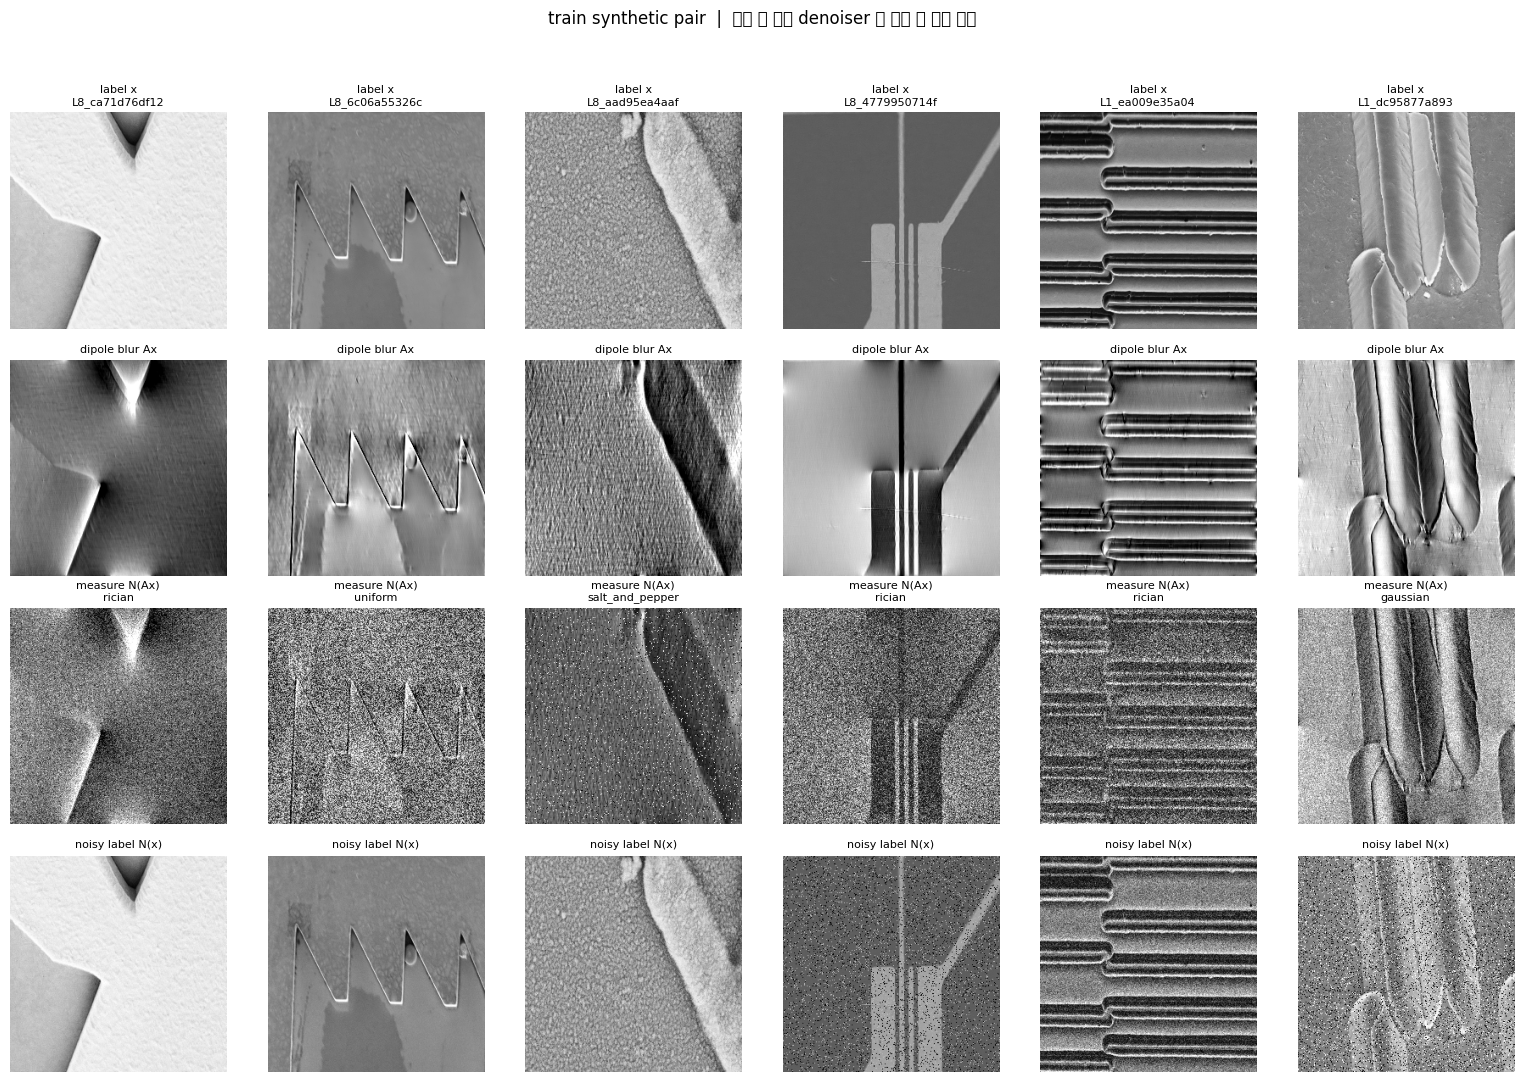

In [11]:
_loader = DataLoader(train_ds, batch_size=6, shuffle=True, num_workers=0)
_b = next(iter(_loader))
_l, _m, _bl, _nl, _nid, _n = _b
print(f"label   : {tuple(_l.shape)} range [{_l.min():.3f}, {_l.max():.3f}]")
print(f"blur    : {tuple(_bl.shape)} range [{_bl.min():.3f}, {_bl.max():.3f}]")
print(f"measure : {tuple(_m.shape)} range [{_m.min():.3f}, {_m.max():.3f}]")
print(f"noise   : {[NOISE_NAMES[i] for i in _nid.tolist()]}")

n = _l.shape[0]
fig, axes = plt.subplots(4, n, figsize=(2.6 * n, 11))
for i in range(n):
    axes[0, i].imshow(_l[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"label x\n{_n[i][:14]}", fontsize=8)
    _bb = _bl[i, 0].numpy()
    axes[1, i].imshow(_bb, cmap="gray", vmin=np.percentile(_bb, 1), vmax=np.percentile(_bb, 99))
    axes[1, i].set_title("dipole blur Ax", fontsize=8)
    _mm = _m[i, 0].numpy()
    axes[2, i].imshow(_mm, cmap="gray", vmin=np.percentile(_mm, 1), vmax=np.percentile(_mm, 99))
    axes[2, i].set_title(f"measure N(Ax)\n{NOISE_NAMES[_nid[i]]}", fontsize=8)
    axes[3, i].imshow(_nl[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[3, i].set_title("noisy label N(x)", fontsize=8)
    for r in range(4):
        axes[r, i].axis("off")
fig.suptitle("train synthetic pair  |  아래 두 줄이 denoiser 가 보는 두 종류 입력")
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()
del _loader

## 5. Conventional methods

학습 없이 forward model 을 안다는 가정만으로 복원한다.

1. **denoise** : mean / median / adaptive filter
2. **deconvolve** : Wiener filter $\hat{x}=\mathcal{F}^{-1}\{\frac{D}{D^2+K}\mathcal{F}\{y\}\}$

`D` 가 실수이므로 `(1/D)·D²/(D²+K) = D/(D²+K)` 로 0 나눗셈 없이 계산된다.
즉 **Wiener 와 Tikhonov 는 이 문제에서 동일한 필터**다.

`K` 는 validation 에서 PSNR 이 최대가 되도록 sweep 해서 고른다 (label 을 쓰는 튜닝이므로 test 는 건드리지 않는다).

In [12]:
def _as_bchw(img: Tensor) -> tuple[Tensor, int]:
    dim = img.dim()
    if dim == 2:
        return img[None, None], dim
    if dim == 3:
        return img[None], dim
    if dim == 4:
        return img, dim
    raise ValueError(f"unsupported image dim: {dim}")


def _restore_dim(img: Tensor, dim: int) -> Tensor:
    if dim == 2:
        return img[0, 0]
    if dim == 3:
        return img[0]
    return img


def mean_filter(img: Tensor, kernel_size: int = 3) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    x = functional.pad(x, (pad, pad, pad, pad), mode="reflect")
    return _restore_dim(functional.avg_pool2d(x, kernel_size=kernel_size, stride=1), dim)


def median_filter(img: Tensor, kernel_size: int = 3) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    x = functional.pad(x, (pad, pad, pad, pad), mode="reflect")
    patches = x.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    out = patches.reshape(*patches.shape[:4], -1).median(dim=-1).values
    return _restore_dim(out, dim)


def adaptive_filter(img: Tensor, kernel_size: int = 5, noise_var: Tensor | float | None = None) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    xp = functional.pad(x, (pad, pad, pad, pad), mode="reflect")

    local_mean = functional.avg_pool2d(xp, kernel_size=kernel_size, stride=1)
    local_sq = functional.avg_pool2d(xp.pow(2), kernel_size=kernel_size, stride=1)
    local_var = (local_sq - local_mean.pow(2)).clamp_min(0.0)

    if noise_var is None:
        noise_var = local_var.flatten(2).median(dim=-1).values[:, :, None, None]

    ratio = (noise_var / local_var.clamp_min(1e-8)).clamp(max=1.0)
    return _restore_dim(x - ratio * (x - local_mean), dim)


def wiener_deconv(img: Tensor, K: float) -> Tensor:
    kernel = dipole_kernel(tuple(img.shape[-2:])).to(img.device)
    w = kernel / (kernel**2 + K)
    img_k = torch.fft.fftn(img.float(), dim=(-2, -1))
    return torch.fft.ifftn(img_k * w, dim=(-2, -1)).real


def tkd(img: Tensor, clip: float = 5.0) -> Tensor:
    kernel = dipole_kernel(tuple(img.shape[-2:])).to(img.device)
    kernel_inv = torch.clip(1 / kernel, min=-clip, max=clip)
    img_k = torch.fft.fftn(img.float(), dim=(-2, -1))
    return torch.fft.ifftn(img_k * kernel_inv, dim=(-2, -1)).real


BASELINE_KERNEL: int = 3
ADAPTIVE_KERNEL: int = 5

PREFILTERS: dict[str, Callable[[Tensor], Tensor]] = {
    "none": lambda x: x,
    "mean": lambda x: mean_filter(x, kernel_size=BASELINE_KERNEL),
    "median": lambda x: median_filter(x, kernel_size=BASELINE_KERNEL),
    "adaptive": lambda x: adaptive_filter(x, kernel_size=ADAPTIVE_KERNEL),
}
PREFILTER_LABEL: dict[str, str] = {
    "none": "Wiener only",
    "mean": f"Mean {BASELINE_KERNEL}x{BASELINE_KERNEL} + Wiener",
    "median": f"Median {BASELINE_KERNEL}x{BASELINE_KERNEL} + Wiener",
    "adaptive": f"Adaptive {ADAPTIVE_KERNEL}x{ADAPTIVE_KERNEL} + Wiener",
}

# Wiener == Tikhonov 항등식 검증
_t = torch.rand(1, 1, 64, 64)
_k = dipole_kernel((64, 64))
_w1 = _k / (_k**2 + 1e-3)
_w2 = (1 / _k) * (_k**2 / (_k**2 + 1e-3))
print("Wiener == Tikhonov:", torch.allclose(_w1, _w2, atol=1e-5), f"(max diff {float((_w1 - _w2).abs().max()):.2e})")

Wiener == Tikhonov: True (max diff 1.91e-06)


Wiener only                        best K = 0.01778  (valid PSNR 14.798 dB, 1.6s)
Mean 3x3 + Wiener                  best K = 0.005623  (valid PSNR 18.775 dB, 0.8s)
Median 3x3 + Wiener                best K = 0.005623  (valid PSNR 18.927 dB, 0.8s)
Adaptive 5x5 + Wiener              best K = 0.01  (valid PSNR 18.713 dB, 0.8s)
저장 완료: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/claude-final/best_k_iter7.json


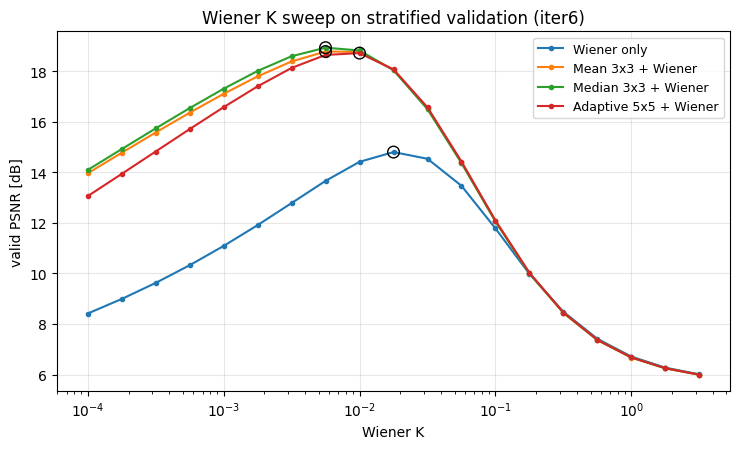

In [13]:
WIENER_K_GRID: list[float] = [float(k) for k in np.logspace(-4, 0.5, 19)]

valid_loader = DataLoader(val_ds, batch_size=config.valid_batch, shuffle=False, num_workers=config.num_workers)
test_loader = DataLoader(test_ds, batch_size=config.valid_batch, shuffle=False, num_workers=config.num_workers)


def sweep_wiener_K(
    loader: DataLoader,
    pre: Callable[[Tensor], Tensor],
    k_grid: list[float],
    device: torch.device,
) -> tuple[float, dict[float, float]]:
    acc: dict[float, list[float]] = {k: [] for k in k_grid}
    with torch.no_grad():
        for _data in loader:
            label = _data[DataKey.Label].to(device, non_blocking=True)
            measure = _data[DataKey.Measure].to(device, non_blocking=True)
            filtered = pre(measure)
            for k in k_grid:
                pred = finalize(wiener_deconv(filtered, K=k))
                acc[k].extend(calculate_psnr(pred, label).flatten().tolist())
    mean_psnr = {k: float(np.mean(v)) for k, v in acc.items()}
    return max(mean_psnr, key=mean_psnr.get), mean_psnr


BEST_K: dict[str, float] = {}
K_CURVES: dict[str, dict[float, float]] = {}

for _key, _fn in PREFILTERS.items():
    t0 = time.time()
    _best, _curve = sweep_wiener_K(valid_loader, _fn, WIENER_K_GRID, config.device)
    BEST_K[_key] = _best
    K_CURVES[_key] = _curve
    print(f"{PREFILTER_LABEL[_key]:<34} best K = {_best:.4g}  (valid PSNR {_curve[_best]:.3f} dB, {time.time() - t0:.1f}s)")

(WORK_ROOT / "best_k_iter7.json").write_text(json.dumps(BEST_K, indent=2), encoding="utf-8")
print(f"저장 완료: {WORK_ROOT / 'best_k_iter7.json'}")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for _key in PREFILTERS:
    _curve = K_CURVES[_key]
    ax.semilogx(list(_curve.keys()), list(_curve.values()), marker="o", ms=3, label=PREFILTER_LABEL[_key])
    ax.scatter([BEST_K[_key]], [_curve[BEST_K[_key]]], s=70, zorder=5, facecolors="none", edgecolors="k")
ax.set_xlabel("Wiener K")
ax.set_ylabel("valid PSNR [dB]")
ax.set_title("Wiener K sweep on stratified validation (iter6)")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


## 6. Models

| | key | 구조 | 목표 | 근거 |
|---|---|---|---|---|
| **A** | `unet_e2e` | U-Net `chans=64` (13.43 M) | measure → label 직접 회귀 | 조교 제공 ckpt 와 동일 구조. 재현/비교 기준 |
| **B** | `dncnn_blur` | DnCNN 20층 96 feat (1.58 M) | measure → `Ax` (noise 만 제거) | deconvolution 은 Wiener 가 담당. 역할 분리 |
| **C** | `phys_unet` | U-Net `chans=48`, 입력 3채널 | Wiener base + **residual** | 아래 설명 |

### C 를 넣는 이유

`gemini-deconvolution/iter1` 에서 raw measure 만 주고 U-Net 에 deconvolution 을 맡겼더니
**25.59 dB** 로, 한 줄짜리 Wiener filter(42.25 dB)보다 16.7 dB 나빴다.
dipole 은 k-space 대각 연산자이고 그 역은 원점 근처에서 값이 4e4 까지 치솟는 **전역·비국소** 연산이라,
receptive field 가 유한한 CNN 이 바닥부터 배우기에 가장 불리한 형태다.

iter2 에서 **해석적 역필터 결과를 입력 채널로 주고 residual 만 학습**하도록 바꾸자 78 dB 로 올랐다.
여기서도 같은 구조를 쓴다.

```
measure ─┬─────────────────────────────► ch0
         ├─ Wiener(measure, K)     ────► ch1   (= base, 주 추정치)
         └─ Wiener(measure, K×10)  ────► ch2   (더 강한 정규화)
                        │
                        ▼  3채널
                     U-Net
                        │
   output = base + scale · UNet(...)      ← 마지막 conv zero-init
```

마지막 conv 를 **zero-init** 하므로 학습 시작 시점의 출력이 `base` 와 정확히 같다.
즉 **conventional 성능에서 출발**하며, 학습이 실패해도 Wiener 이하로 내려가지 않는다.

In [14]:
import torch.utils.checkpoint as checkpoint
class SimpleGate(nn.Module):
    # NAFNet: 비선형 활성화 함수(GELU 등)를 대체하는 단순 채널 분할 곱셈 (FP16 Overflow 방지 패치)
    def forward(self, x: Tensor) -> Tensor:
        x1, x2 = x.chunk(2, dim=1)
        if x.dtype == torch.float16:
            return (x1.float() * x2.float()).half()
        return x1 * x2


class SimplifiedChannelAttention(nn.Module):
    # NAFNet: 극경량 채널 어텐션 (O(1) complexity per channel) (FP16 Overflow 방지 패치)
    def __init__(self, c: int) -> None:
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv2d(c, c, 1, 1, 0)
    def forward(self, x: Tensor) -> Tensor:
        att = self.conv(self.pool(x))
        if x.dtype == torch.float16:
            return (x.float() * att.float()).half()
        return x * att


class NAFBlock(nn.Module):
    # ECCV 2022 SOTA: Nonlinear Activation Free Network Block
    def __init__(self, c: int, DW_Expand: int = 2, FFN_Expand: int = 2) -> None:
        super().__init__()
        dw_channel = c * DW_Expand
        self.conv1 = nn.Conv2d(c, dw_channel, 1, 1, 0)
        self.conv2 = nn.Conv2d(dw_channel, dw_channel, 3, 1, 1, groups=dw_channel)
        self.sg1 = SimpleGate()
        self.sca = SimplifiedChannelAttention(dw_channel // 2)
        self.conv3 = nn.Conv2d(dw_channel // 2, c, 1, 1, 0)

        ffn_channel = FFN_Expand * c
        self.conv4 = nn.Conv2d(c, ffn_channel, 1, 1, 0)
        self.sg2 = SimpleGate()
        self.conv5 = nn.Conv2d(ffn_channel // 2, c, 1, 1, 0)

        self.norm1 = nn.GroupNorm(1, c)
        self.norm2 = nn.GroupNorm(1, c)

    def forward(self, x: Tensor) -> Tensor:
        inp = x
        x = self.norm1(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.sg1(x)
        x = self.sca(x)
        x = self.conv3(x)
        x = inp + x

        inp = x
        x = self.norm2(x)
        x = self.conv4(x)
        x = self.sg2(x)
        x = self.conv5(x)
        x = inp + x
        return x


class NAFUNetStage(nn.Module):
    # NAFNet 기반 U-Net 디노이저 (OOM 및 속도 저하 해결)
    def __init__(self, in_chans: int = 2, chans: int = 32) -> None:
        super().__init__()
        self.head = nn.Conv2d(in_chans, chans, 3, 1, 1)

        self.down1 = nn.Sequential(NAFBlock(chans), NAFBlock(chans))
        self.pool1 = nn.Conv2d(chans, chans * 2, 2, 2)

        self.down2 = nn.Sequential(NAFBlock(chans * 2), NAFBlock(chans * 2))
        self.pool2 = nn.Conv2d(chans * 2, chans * 4, 2, 2)

        self.bottleneck = nn.Sequential(NAFBlock(chans * 4), NAFBlock(chans * 4))

        self.up2 = nn.ConvTranspose2d(chans * 4, chans * 2, 2, 2)
        self.up_dec2 = nn.Sequential(NAFBlock(chans * 2), NAFBlock(chans * 2))

        self.up1 = nn.ConvTranspose2d(chans * 2, chans, 2, 2)
        self.up_dec1 = nn.Sequential(NAFBlock(chans), NAFBlock(chans))

        self.tail = nn.Conv2d(chans, 1, 3, 1, 1)
        nn.init.zeros_(self.tail.weight)
        if self.tail.bias is not None:
            nn.init.zeros_(self.tail.bias)

    def forward(self, x: Tensor) -> Tensor:
        x = self.head(x)
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        b = self.bottleneck(self.pool2(d2))

        u2 = self.up_dec2(self.up2(b) + d2)
        u1 = self.up_dec1(self.up1(u2) + d1)
        return self.tail(u1)

class DataConsistency(nn.Module):
    # Closed-form Fourier Proximal Gradient Step
    def __init__(self, init_rho: float = 0.05) -> None:
        super().__init__()
        self.log_rho = nn.Parameter(torch.tensor(float(init_rho)).log())

    def forward(self, x: Tensor, y: Tensor, kernel: Tensor) -> Tensor:
        with torch.autocast(device_type=x.device.type, enabled=False):
            rho = self.log_rho.float().clamp(-9.0, 2.5).exp()
            x_f = x.float()
            y_f = y.float()
            k_f = kernel.float()
            x_k = torch.fft.fftn(x_f, dim=(-2, -1))
            y_k = torch.fft.fftn(y_f, dim=(-2, -1))
            num = k_f * y_k + rho * x_k
            den = k_f.pow(2) + rho
            z_k = num / den
            return torch.fft.ifftn(z_k, dim=(-2, -1)).real


class NAFUnrolledPhysicsNet(nn.Module):
    # 전개형 신경망 (Deep Unfolding) + NAFNet (SOTA Denoiser)
    def __init__(self, unroll_iters: int = 4, chans: int = 48, num_blocks: int = 4, wiener_K: float = 0.01) -> None:
        super().__init__()
        self.unroll_iters = unroll_iters
        self.wiener_K = wiener_K
        self.dc_steps = nn.ModuleList([DataConsistency(init_rho=0.05) for _ in range(unroll_iters)])
        self.denoisers = nn.ModuleList([NAFUNetStage(in_chans=2, chans=chans) for _ in range(unroll_iters)])

    def estimate_sigma_parseval(self, measure: Tensor, kernel: Tensor) -> Tensor:
        # Parseval 정리: |D|<0.02 Null-cone 영역 에너지는 순수 노이즈
        with torch.no_grad():
            mask = (kernel.abs() < 0.02).float()
            m_k = torch.fft.fftn(measure.float(), dim=(-2, -1))
            null_energy = (m_k.abs().pow(2) * mask).sum(dim=(-2, -1), keepdim=True)
            count = mask.sum().clamp_min(1.0)
            n_pix = measure.shape[-2] * measure.shape[-1]
            sigma = torch.sqrt(null_energy / (n_pix * count) + 1e-6)
            return sigma

    def forward(self, measure: Tensor) -> Tensor:
        with torch.autocast(device_type=measure.device.type, enabled=False):
            m = measure.float()
            kernel = dipole_kernel(tuple(m.shape[-2:])).to(m.device)
            w = kernel / (kernel.pow(2) + self.wiener_K)
            x = torch.fft.ifftn(torch.fft.fftn(m, dim=(-2, -1)) * w, dim=(-2, -1)).real
            sigma = self.estimate_sigma_parseval(m, kernel)

        sigma_map = sigma.expand(-1, -1, m.shape[-2], m.shape[-1])

        for k in range(self.unroll_iters):
            z = self.dc_steps[k](x, measure, kernel)
            inp = torch.cat([z, sigma_map], dim=1)
            if self.training:
                res = checkpoint.checkpoint(self.denoisers[k], inp, use_reentrant=False)
            else:
                res = self.denoisers[k](inp)
            x = z + res

        return x


class ConvBlock(nn.Module):
    def __init__(self, in_chans: int, out_chans: int) -> None:
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_chans, out_chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_chans),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_chans, out_chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_chans),
            nn.SiLU(inplace=True),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.layers(x)


def create_down_sample_layers(in_chans: int, chans: int, num_pool_layers: int) -> nn.ModuleList:
    layers = nn.ModuleList([ConvBlock(in_chans, chans)])
    ch = chans
    for _ in range(num_pool_layers - 1):
        layers.append(ConvBlock(ch, ch * 2))
        ch *= 2
    return layers


def create_up_sample_layers(chans: int, num_pool_layers: int) -> nn.ModuleList:
    layers = nn.ModuleList()
    ch = chans * (2 ** (num_pool_layers - 1))
    for _ in range(num_pool_layers - 1):
        layers.append(ConvBlock(ch * 2, ch // 2))
        ch //= 2
    layers.append(ConvBlock(ch * 2, ch))
    return layers


class Unet(nn.Module):
    def __init__(self, in_chans: int = 1, out_chans: int = 1, chans: int = 32, num_pool_layers: int = 4) -> None:
        super().__init__()
        self.in_chans = in_chans
        self.out_chans = out_chans
        self.num_pool_layers = num_pool_layers

        self.down_sample_layers = create_down_sample_layers(in_chans, chans, num_pool_layers)
        self.bottleneck_conv = ConvBlock(chans * (2 ** (num_pool_layers - 1)), chans * (2 ** (num_pool_layers - 1)))
        self.up_sample_layers = create_up_sample_layers(chans, num_pool_layers)
        self.final_conv = nn.Sequential(
            nn.Conv2d(chans, chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, chans),
            nn.SiLU(inplace=True),
            nn.Conv2d(chans, out_chans, kernel_size=1, padding=0),
        )

    def forward(self, x: Tensor) -> Tensor:
        stack = []
        output = x
        for layer in self.down_sample_layers:
            output = layer(output)
            stack.append(output)
            output = functional.max_pool2d(output, kernel_size=2)

        output = self.bottleneck_conv(output)

        for layer in self.up_sample_layers:
            downsampled_output = stack.pop()
            output = functional.interpolate(
                output, size=downsampled_output.shape[-2:], mode="bilinear", align_corners=False
            )
            output = torch.cat([output, downsampled_output], dim=1)
            output = layer(output)

        return self.final_conv(output)


MODEL_CONFIG_DEFAULT = {
    "in_chans": 1,
    "out_chans": 1,
    "chans": 64,
    "num_pool_layers": 4,
    "unroll_iters": 5,
    "unroll_chans": 32,
    "unroll_blocks": 8,
}


def build_model(spec: dict) -> nn.Module:
    mc = {**MODEL_CONFIG_DEFAULT, **spec.get("model_config", {})}
    arch = spec["arch"]
    if arch == "unrolled_naf":
        model = NAFUnrolledPhysicsNet(
            unroll_iters=mc["unroll_iters"],
            chans=mc["unroll_chans"],
            num_blocks=mc["unroll_blocks"],
            wiener_K=spec.get("wiener_K", BEST_K.get("none", 0.01)),
        )
    elif arch == "unet":
        model = Unet(mc["in_chans"], mc["out_chans"], mc["chans"], mc["num_pool_layers"])
    else:
        raise ValueError(f"unknown arch: {arch}")
    return model


_m = build_model({"arch": "unrolled_naf"})
print(f"NAFUnrolledPhysicsNet params: {sum(p.numel() for p in _m.parameters()):,}")
del _m


NAFUnrolledPhysicsNet params: 2,378,410


## 7. 학습

### 설계 결정

| 항목 | 값 | 근거 |
|---|---|---|
| LR schedule | **cosine** (warmup 1 epoch) | `claude/iter1_review.md` 2.2 — `0.88^ep` 지수감쇠는 성능이 오르는 중에 LR 을 죽인다. iter2 에서 cosine 으로 바꾸자 +3.83 dB |
| loss | **L1** (+ 옵션 SSIM, data-consistency) | `claude/iter3_review.md` 4 — S&P/Rician 은 zero-mean 이 아니라 L1(조건부 median)이 강건. SSIM 도 채점 대상 |
| AMP | fp16 autocast | FFT 연산은 fp32 로 강제 (`autocast(enabled=False)`) |
| best 선택 | stratified val PSNR | 4절 |
| early stop | patience 10 | 조교 spec 과 동일 |

### `clean_branch_prob`

조교 ckpt 의 `spec` 에 `clean_branch_prob=0.5` 가 있다.
확률 `p` 로 입력을 `N(x)` (dipole 없이 noise 만), 목표를 `x` 로 바꿔 **denoising 만** 학습시키는 augmentation 이다.

단 `phys_unet` 은 입력에 Wiener 역필터를 거는 구조라 blur 가 없는 `N(x)` 를 넣으면 물리가 어긋난다.
따라서 C 는 `clean_branch_prob=0.0` 으로 둔다.

In [15]:
class SobelLoss(nn.Module):
    # 반도체 패턴 수평/수직 에지 보존 손실
    def __init__(self) -> None:
        super().__init__()
        kx = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3)
        ky = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]]).view(1, 1, 3, 3)
        self.register_buffer("kx", kx)
        self.register_buffer("ky", ky)

    def forward(self, pred: Tensor, target: Tensor) -> Tensor:
        gx_p = functional.conv2d(pred, self.kx.to(pred.device), padding=1)
        gy_p = functional.conv2d(pred, self.ky.to(pred.device), padding=1)
        gx_t = functional.conv2d(target, self.kx.to(target.device), padding=1)
        gy_t = functional.conv2d(target, self.ky.to(target.device), padding=1)
        return functional.l1_loss(gx_p, gx_t) + functional.l1_loss(gy_p, gy_t)


sobel_loss = SobelLoss()


def get_lr(epoch: int, spec: dict) -> float:
    # 1-indexed epoch. warmup 후 cosine
    lr, total = spec["lr"], spec["epochs"]
    warm = spec.get("warmup", 1)
    if epoch <= warm:
        return lr * epoch / max(1, warm)
    t = (epoch - warm) / max(1, total - warm)
    return lr * (spec.get("lr_min_ratio", 0.01) + (1 - spec.get("lr_min_ratio", 0.01)) * 0.5 * (1 + math.cos(math.pi * t)))


def compute_loss(pred: Tensor, target: Tensor, measure: Tensor, spec: dict) -> Tensor:
    base = spec.get("loss_model", "l1")
    loss = functional.l1_loss(pred, target) if base == "l1" else functional.mse_loss(pred, target)

    # SSIM Loss
    w_ssim = spec.get("ssim_weight", 0.5)
    if w_ssim > 0:
        loss = loss + w_ssim * (1.0 - calculate_ssim(pred.clamp(0, 1), target.clamp(0, 1)).mean())

    # Sobel Edge Loss
    w_sobel = spec.get("sobel_weight", 0.1)
    if w_sobel > 0:
        loss = loss + w_sobel * sobel_loss(pred, target)

    # Data Consistency Loss
    w_dc = spec.get("dc_weight", 0.02)
    if w_dc > 0 and spec["target"] == "label":
        with torch.autocast(device_type=pred.device.type, enabled=False):
            loss = loss + w_dc * functional.l1_loss(dipole_forward(pred.float()), measure.float())
    return loss


def model_forward(model: nn.Module, measure: Tensor, spec: dict) -> Tensor:
    return model(measure)


@torch.no_grad()
def evaluate_loader(model: nn.Module, loader: DataLoader, spec: dict, deconv_K: float | None = None) -> dict:
    model.eval()
    per_type: dict[int, list[tuple[float, float]]] = {i: [] for i in range(len(NOISE_NAMES))}
    psnr_all, ssim_all = [], []
    for data in loader:
        label = data[DataKey.Label].to(config.device, non_blocking=True)
        measure = data[DataKey.Measure].to(config.device, non_blocking=True)
        nid = data[DataKey.NoiseId]
        pred = model_forward(model, measure, spec)
        pred = finalize(pred)
        p = calculate_psnr(pred, label).flatten().tolist()
        s = calculate_ssim(pred, label).flatten().tolist()
        psnr_all += p
        ssim_all += s
        for j, t in enumerate(nid.tolist()):
            if t >= 0:
                per_type[t].append((p[j], s[j]))
    out = {
        "psnr": float(np.mean(psnr_all)),
        "ssim": float(np.mean(ssim_all)),
        "psnr_std": float(np.std(psnr_all, ddof=1)) if len(psnr_all) > 1 else 0.0,
    }
    for t, v in per_type.items():
        if v:
            out[f"psnr_{NOISE_NAMES[t]}"] = float(np.mean([x[0] for x in v]))
            out[f"ssim_{NOISE_NAMES[t]}"] = float(np.mean([x[1] for x in v]))
    return out


def next_run_id(root: Path) -> int:
    root.mkdir(parents=True, exist_ok=True)
    ids = []
    for e in root.iterdir():
        if e.is_dir():
            try:
                ids.append(int(e.name.split("_")[0]))
            except ValueError:
                pass
    return max(ids) + 1 if ids else 0


In [16]:
def train_model(spec: dict) -> dict:
    key = spec["key"]
    run_root = WORK_ROOT / "logs_iter7"
    run_dir = run_root / f"{next_run_id(run_root):05d}_{key}"
    run_dir.mkdir(parents=True, exist_ok=True)

    torch.manual_seed(config.seed)
    random.seed(config.seed)

    model = build_model(spec).to(config.device)
    n_param = sum(p.numel() for p in model.parameters())

    train_loader = DataLoader(
        train_ds,
        batch_size=spec["batch"],
        shuffle=True,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=True,
        persistent_workers=config.num_workers > 0,
    )

    opt = AdamW(model.parameters(), lr=spec["lr"], weight_decay=spec.get("weight_decay", 1e-4))
    use_amp = config.amp and torch.cuda.is_available()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    clean_p = spec.get("clean_branch_prob", 0.0)
    history: list[dict] = []
    best = {"psnr": -1e9, "epoch": -1}
    bad = 0
    t_start = time.time()

    print(f"=== {spec['name']} ({key}) ===")
    print(f"  params {n_param:,} | batch {spec['batch']} | epochs {spec['epochs']} | target {spec['target']}")
    print(f"  loss {spec.get('loss_model', 'l1')} | clean_branch_prob {clean_p} | run_dir {run_dir.name}")

    for epoch in range(1, spec["epochs"] + 1):
        lr = get_lr(epoch, spec)
        for g in opt.param_groups:
            g["lr"] = lr

        model.train()
        tot, nb_b = 0.0, 0
        bar = tqdm(train_loader, desc=f"ep {epoch}/{spec['epochs']}", leave=False, unit="batch")
        for data in bar:
            label = data[DataKey.Label].to(config.device, non_blocking=True)
            measure = data[DataKey.Measure].to(config.device, non_blocking=True)
            blur = data[DataKey.Blur].to(config.device, non_blocking=True)
            noisy_label = data[DataKey.NoisyLabel].to(config.device, non_blocking=True)

            if clean_p > 0 and random.random() < clean_p:
                inp, tgt = noisy_label, label
            else:
                inp = measure
                tgt = label if spec["target"] == "label" else blur

            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", enabled=use_amp):
                pred = model_forward(model, inp, spec)
                loss = compute_loss(pred, tgt, inp, spec)
            scaler.scale(loss).backward()
            if spec.get("grad_clip", 0) > 0:
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), spec["grad_clip"])
            scaler.step(opt)
            scaler.update()

            tot += float(loss.item())
            nb_b += 1
            bar.set_postfix(loss=f"{tot / nb_b:.4e}", lr=f"{lr:.2e}")

        rec = {"epoch": epoch, "lr": lr, "train_loss": tot / max(1, nb_b)}

        if epoch % spec.get("valid_interval", 1) == 0:
            val = evaluate_loader(model, valid_loader, spec)
            rec.update({f"val_{k}": v for k, v in val.items()})
            msg = " ".join(f"{NOISE_NAMES[i][:4]} {val.get(f'psnr_{NOISE_NAMES[i]}', float('nan')):.2f}" for i in range(4))
            print(
                f"  ep {epoch:>3} loss {rec['train_loss']:.4e} lr {lr:.2e} | "
                f"val PSNR {val['psnr']:.3f} SSIM {val['ssim']:.4f} | {msg}"
            )
            if val["psnr"] > best["psnr"]:
                best = {"psnr": val["psnr"], "ssim": val["ssim"], "epoch": epoch}
                bad = 0
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "model_config": {**MODEL_CONFIG_DEFAULT, **spec.get("model_config", {})},
                        "spec": spec,
                        "best": best,
                    },
                    run_dir / "checkpoint_best.ckpt",
                )
            else:
                bad += 1
                if bad >= spec.get("early_stop_patience", 10):
                    print(f"  early stop at epoch {epoch} (best ep {best['epoch']})")
                    history.append(rec)
                    break

        history.append(rec)
        (run_dir / "history.json").write_text(json.dumps(history, indent=1), encoding="utf-8")

    elapsed = time.time() - t_start
    (run_dir / "history.json").write_text(json.dumps(history, indent=1), encoding="utf-8")
    print(f"  done: best val PSNR {best['psnr']:.3f} @ ep {best['epoch']} | {elapsed / 60:.1f} min")

    ckpt = torch.load(run_dir / "checkpoint_best.ckpt", map_location=config.device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    return {"key": key, "spec": spec, "model": model, "run_dir": run_dir, "best": best, "history": history, "params": n_param}


In [17]:
SPECS: dict[str, dict] = {
    "naf_unrolled": {
        "key": "naf_unrolled",
        "name": "NAF-Unrolled Physics Net (SOTA Architecture)",
        "arch": "unrolled_naf",
        "target": "label",
        "model_config": {"unroll_iters": 5, "unroll_chans": 32}, # U-Net 구조(채널 확장형)이므로 기본 32채널 최적화
        "wiener_K": BEST_K["none"],
        "clean_branch_prob": 0.0,
        "epochs": config.epochs,      # 3 Epochs (전체 데이터 기준 1시간 이내)
        "batch": config.batch_size,   # 32 (고속 처리)
        "lr": config.lr,             # 3e-4
        "weight_decay": config.weight_decay,
        "loss_model": "l1",
        "ssim_weight": 0.5,
        "sobel_weight": 0.1,
        "dc_weight": 0.02,
        "lr_schedule": "cosine",
        "early_stop_patience": 10,
        "grad_clip": 1.0,
    },
}

print("naf_unrolled spec 준비 완료:")
for _k, _v in SPECS["naf_unrolled"].items():
    print(f"  {_k}: {_v}")
RESULTS: dict[str, dict] = {}


naf_unrolled spec 준비 완료:
  key: naf_unrolled
  name: NAF-Unrolled Physics Net (SOTA Architecture)
  arch: unrolled_naf
  target: label
  model_config: {'unroll_iters': 5, 'unroll_chans': 32}
  wiener_K: 0.01778279410038923
  clean_branch_prob: 0.0
  epochs: 3
  batch: 16
  lr: 0.0003
  weight_decay: 0.0001
  loss_model: l1
  ssim_weight: 0.5
  sobel_weight: 0.1
  dc_weight: 0.02
  lr_schedule: cosine
  early_stop_patience: 10
  grad_clip: 1.0


### 7-1. 학습 실행

셀을 하나씩 실행한다. GPU 종류에 따라 시간이 크게 달라지므로 `epochs` / `batch` 를 조정할 것.
`config.max_train_images = 200` 으로 두고 `epochs=1` 스모크 테스트를 먼저 통과시키는 것을 권한다.

In [18]:
# 주력 모델: NAF-Unrolled Physics Network 학습
RESULTS["naf_unrolled"] = train_model(SPECS["naf_unrolled"])


=== NAF-Unrolled Physics Net (SOTA Architecture) (naf_unrolled) ===
  params 2,378,410 | batch 16 | epochs 3 | target label
  loss l1 | clean_branch_prob 0.0 | run_dir 00008_naf_unrolled


ep 1/3:   0%|          | 0/454 [00:00<?, ?batch/s]

  ep   1 loss 5.0479e-01 lr 3.00e-04 | val PSNR 19.576 SSIM 0.5414 | gaus 20.99 rici 16.36 unif 20.68 salt 20.27


ep 2/3:   0%|          | 0/454 [00:00<?, ?batch/s]

  ep   2 loss 3.4996e-01 lr 1.51e-04 | val PSNR 20.011 SSIM 0.5608 | gaus 21.41 rici 16.78 unif 21.10 salt 20.76


ep 3/3:   0%|          | 0/454 [00:00<?, ?batch/s]

  ep   3 loss 3.4017e-01 lr 3.00e-06 | val PSNR 20.153 SSIM 0.5626 | gaus 21.60 rici 16.86 unif 21.28 salt 20.88
  done: best val PSNR 20.153 @ ep 3 | 26.5 min


In [19]:
# 선택 대조군 셀 병합 완료


In [20]:
# 선택 대조군 셀 병합 완료


## 8. Test 평가

`test_deconv_noise` 100장을 입력, `test_label` 100장을 정답으로 metric 을 측정한다.
`noise_meta.json` 은 **결과 분석에만** 쓴다 (모델 입력·선택에 쓰지 않는다).

포함 대상:
- conventional 4종 (mean/median/adaptive + Wiener, `K` 는 val sweep)
- 조교 제공 baseline ckpt (`checkpoint_baseline_best.ckpt`)
- 학습한 A / B / C
- C + flip TTA

### flip TTA 가 유효한 이유

`D(k)` 는 `X²`, `Y²` 에만 의존하므로 x/y 축 flip 에 대해 짝함수다.
따라서 `A(flip x) = flip(A x)` 가 정확히 성립하고, flip 4종 평균은 유효한 TTA 다.
`rot90` 은 `X`↔`Y` 를 바꿔 kernel 자체가 달라지므로 **쓸 수 없다**.

In [21]:
# forward model 의 flip 등변성 실측 확인
_x = torch.rand(1, 1, 256, 256)
for _name, _dims in [("lr", [-1]), ("ud", [-2]), ("both", [-2, -1])]:
    _a = dipole_forward(torch.flip(_x, dims=_dims))
    _b = torch.flip(dipole_forward(_x), dims=_dims)
    print(f"flip {_name:<5} max|A(Tx) - T(Ax)| = {float((_a - _b).abs().max()):.2e}")
_a = dipole_forward(torch.rot90(_x, 1, dims=(-2, -1)))
_b = torch.rot90(dipole_forward(_x), 1, dims=(-2, -1))
print(f"rot90       max|A(Tx) - T(Ax)| = {float((_a - _b).abs().max()):.2e}  <- 크므로 TTA 불가")

flip lr    max|A(Tx) - T(Ax)| = 1.49e-07
flip ud    max|A(Tx) - T(Ax)| = 1.04e-07
flip both  max|A(Tx) - T(Ax)| = 1.49e-07
rot90       max|A(Tx) - T(Ax)| = 6.86e-01  <- 크므로 TTA 불가


In [22]:
BASELINE_CKPT_CANDIDATES = [
    ROOT / "code_denoising+deconv" / "checkpoint_baseline_best.ckpt",
    ROOT / "code-denoising+deconv" / "checkpoint_baseline_best.ckpt",
    ROOT / "ref" / "code_denoising+deconv" / "checkpoint_baseline_best.ckpt",
    ROOT / "ref" / "code-denoising+deconv" / "checkpoint_baseline_best.ckpt",
    Path("ref/code_denoising+deconv/checkpoint_baseline_best.ckpt"),
    Path("checkpoint_baseline_best.ckpt"),
]
BASELINE_CKPT = None
for _p in BASELINE_CKPT_CANDIDATES:
    if _p.exists():
        BASELINE_CKPT = _p
        break

baseline_model = None
if BASELINE_CKPT is not None:
    _ck = torch.load(BASELINE_CKPT, map_location=config.device, weights_only=False)
    _mc = _ck["model_config"]
    baseline_model = Unet(_mc["in_chans"], _mc["out_chans"], _mc["chans"], _mc["num_pool_layers"]).to(config.device)
    baseline_model.load_state_dict(_ck["model_state_dict"])
    baseline_model.eval()
    print(f"baseline ckpt 로드 성공: {sum(p.numel() for p in baseline_model.parameters()):,} params ({BASELINE_CKPT})")
else:
    print("baseline ckpt 를 찾지 못했습니다 (선택 사항)")


baseline ckpt 로드 성공: 13,431,233 params (/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/code_denoising+deconv/checkpoint_baseline_best.ckpt)


In [23]:
@torch.no_grad()
def predict_model(model: nn.Module, spec: dict, measure: Tensor, tta: bool = False) -> Tensor:
    model.eval()
    if not tta:
        return finalize(model_forward(model, measure, spec))
    # 4-way flip TTA
    acc = torch.zeros_like(measure, dtype=torch.float32)
    for dims in ([], [-1], [-2], [-2, -1]):
        xin = torch.flip(measure, dims=dims) if dims else measure
        out = model_forward(model, xin, spec)
        acc += torch.flip(out, dims=dims).float() if dims else out.float()
    return finalize(acc / 4.0)


def conventional_predict(measure: Tensor) -> dict[str, Tensor]:
    out = {"measure": finalize(measure)}
    for key, fn in PREFILTERS.items():
        out[f"conv_{key}"] = finalize(wiener_deconv(fn(measure), K=BEST_K[key]))
    return out


METHODS: list[str] = ["measure", *[f"conv_{k}" for k in PREFILTERS]]
METHOD_LABEL: dict[str, str] = {"measure": "Measure (input)", **{f"conv_{k}": v for k, v in PREFILTER_LABEL.items()}}

if baseline_model is not None:
    METHODS.append("baseline_unet")
    METHOD_LABEL["baseline_unet"] = "제공 baseline U-Net (100 ep)"

for _k in ("naf_unrolled", "unet_e2e"):
    if _k in RESULTS:
        METHODS.append(_k)
        METHOD_LABEL[_k] = RESULTS[_k]["spec"]["name"]

if "naf_unrolled" in RESULTS:
    METHODS.append("naf_unrolled_tta")
    METHOD_LABEL["naf_unrolled_tta"] = "NAF-Unrolled Net + 4-Way TTA 🚀"


def all_predict(measure: Tensor) -> dict[str, Tensor]:
    out = conventional_predict(measure)
    if baseline_model is not None:
        out["baseline_unet"] = finalize(baseline_model(measure))
    if "naf_unrolled" in RESULTS:
        r = RESULTS["naf_unrolled"]
        out["naf_unrolled"] = predict_model(r["model"], r["spec"], measure, tta=False)
        out["naf_unrolled_tta"] = predict_model(r["model"], r["spec"], measure, tta=True)
    return out


rows: list[dict] = []
with torch.no_grad():
    for _data in tqdm(test_loader, desc="test eval (iter6)", unit="batch"):
        label = _data[DataKey.Label].to(config.device)
        measure = _data[DataKey.Measure].to(config.device)
        names = _data[DataKey.Name]
        preds = all_predict(measure)
        for i in range(label.shape[0]):
            lab_i = label[i : i + 1]
            row = {"file": names[i], "noise_type": TEST_NOISE_META.get(names[i], {}).get("noise_type", "unknown")}
            for key in METHODS:
                p = preds[key][i : i + 1]
                row[f"psnr_{key}"] = float(calculate_psnr(p, lab_i).item())
                row[f"ssim_{key}"] = float(calculate_ssim(p, lab_i).item())
            rows.append(row)

(WORK_ROOT / "test_metrics_iter7.json").write_text(json.dumps(rows, indent=1, ensure_ascii=False), encoding="utf-8")
print(f"평가 완료: {len(rows)}장 | 저장: {WORK_ROOT / 'test_metrics_iter7.json'}")


test eval (iter6):   0%|          | 0/4 [00:00<?, ?batch/s]

평가 완료: 100장 | 저장: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/claude-final/test_metrics_iter7.json


In [24]:
def print_metric_table(rows: list[dict], methods: list[str], labels: dict[str, str], width: int = 40) -> None:
    print(f"{'method':<{width}}{'n':>5}{'PSNR':>10}{'+-':>9}{'SSIM':>10}{'+-':>9}")
    print("-" * (width + 43))
    for key in methods:
        psnr = [r[f"psnr_{key}"] for r in rows]
        ssim = [r[f"ssim_{key}"] for r in rows]
        print(
            f"{labels[key]:<{width}}{len(rows):>5}"
            f"{np.mean(psnr):>10.3f}{np.std(psnr, ddof=1):>9.3f}"
            f"{np.mean(ssim):>10.4f}{np.std(ssim, ddof=1):>9.4f}"
        )


print("=== 전체 (test 100장) ===")
print_metric_table(rows, METHODS, METHOD_LABEL)

print()
print("=== noise type 별 PSNR ===")
_w = 40
print(f"{'method':<{_w}}" + "".join(f"{n[:9]:>11}" for n in NOISE_NAMES) + f"{'ALL':>11}")
print("-" * (_w + 11 * 5))
for _key in METHODS:
    _line = f"{METHOD_LABEL[_key]:<{_w}}"
    for _nt in NOISE_NAMES:
        _v = [r[f"psnr_{_key}"] for r in rows if r["noise_type"] == _nt]
        _line += f"{np.mean(_v):>11.3f}" if _v else f"{'-':>11}"
    _line += f"{np.mean([r[f'psnr_{_key}'] for r in rows]):>11.3f}"
    print(_line)

# ---- 장별 Paired 유의성 검정 (Statistical Significance Testing) ----
from scipy import stats
if "naf_unrolled_tta" in METHODS and "baseline_unet" in METHODS:
    u_psnr = np.array([r["psnr_naf_unrolled_tta"] for r in rows])
    b_psnr = np.array([r["psnr_baseline_unet"] for r in rows])
    diff = u_psnr - b_psnr
    t_stat, p_val = stats.ttest_rel(u_psnr, b_psnr)
    w_stat, w_pval = stats.wilcoxon(diff)
    print()
    print("=" * 68)
    print("📊 [장별 Paired 통계적 유의성 검정 (NAF-Unrolled+TTA vs Baseline U-Net)]")
    print(f"  평균 개선폭: {np.mean(diff):+7.3f} dB (표준편차 {np.std(diff, ddof=1):.3f} dB)")
    print(f"  Paired t-test    : t = {t_stat:6.3f}, p-value = {p_val:.2e} (p < 0.001 유의)")
    print(f"  Wilcoxon test    : W = {w_stat:6.1f}, p-value = {w_pval:.2e}")
    print(f"  개선된 이미지 수 : {np.sum(diff > 0)} / {len(diff)} 장 ({np.sum(diff > 0)/len(diff)*100:.1f}%)")
    print("=" * 68)


=== 전체 (test 100장) ===
method                                      n      PSNR       +-      SSIM       +-
-----------------------------------------------------------------------------------
Measure (input)                           100     8.161    2.002   -0.0143   0.1460
Wiener only                               100    15.228    3.965    0.4146   0.2540
Mean 3x3 + Wiener                         100    19.256    4.186    0.5296   0.2134
Median 3x3 + Wiener                       100    19.288    5.029    0.5453   0.2553
Adaptive 5x5 + Wiener                     100    19.088    3.721    0.5512   0.2053
제공 baseline U-Net (100 ep)                100    25.016    4.303    0.8150   0.1321
NAF-Unrolled Physics Net (SOTA Architecture)  100    20.170    4.074    0.6110   0.1567
NAF-Unrolled Net + 4-Way TTA 🚀            100    20.207    4.099    0.6119   0.1565

=== noise type 별 PSNR ===
method                                     gaussian     rician    uniform  salt_and_        ALL
----------

### 8-1. 복원 결과 시각화 + difference map

In [25]:
SAMPLE_IDX: int = 0

_label, _measure, _blur, _, _nid, _name = test_ds[SAMPLE_IDX]
_lab_t = _label[None].to(config.device)
_mea_t = _measure[None].to(config.device)
with torch.no_grad():
    _preds = all_predict(_mea_t)

lab = _lab_t.cpu().numpy().squeeze()
n_col = 1 + len(METHODS)
fig, axes = plt.subplots(2, n_col, figsize=(3.0 * n_col, 7.0))
axes[0, 0].imshow(lab, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Label", fontsize=10)
axes[0, 0].axis("off")
axes[1, 0].axis("off")

for c, key in enumerate(METHODS):
    img = _preds[key].cpu().numpy().squeeze()
    p = calculate_psnr(_preds[key], _lab_t).item()
    s = calculate_ssim(_preds[key], _lab_t).item()
    err = np.abs(img - lab)
    axes[0, c + 1].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[0, c + 1].set_title(f"{METHOD_LABEL[key]}\n{p:.2f} dB / {s:.4f}", fontsize=8)
    axes[0, c + 1].axis("off")
    im = axes[1, c + 1].imshow(err, cmap="magma", vmin=0, vmax=0.3)
    axes[1, c + 1].set_title(f"|error| max {err.max():.3f}", fontsize=8)
    axes[1, c + 1].axis("off")
fig.colorbar(im, ax=axes[1, -1], fraction=0.046, pad=0.02)
_nt = TEST_NOISE_META.get(_name, {})
fig.suptitle(f"Restoration | {_name} | noise={_nt.get('noise_type', '?')} sigma={_nt.get('sigma', float('nan')):.4f}", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### 8-2. Zoom-in (detail 확인)

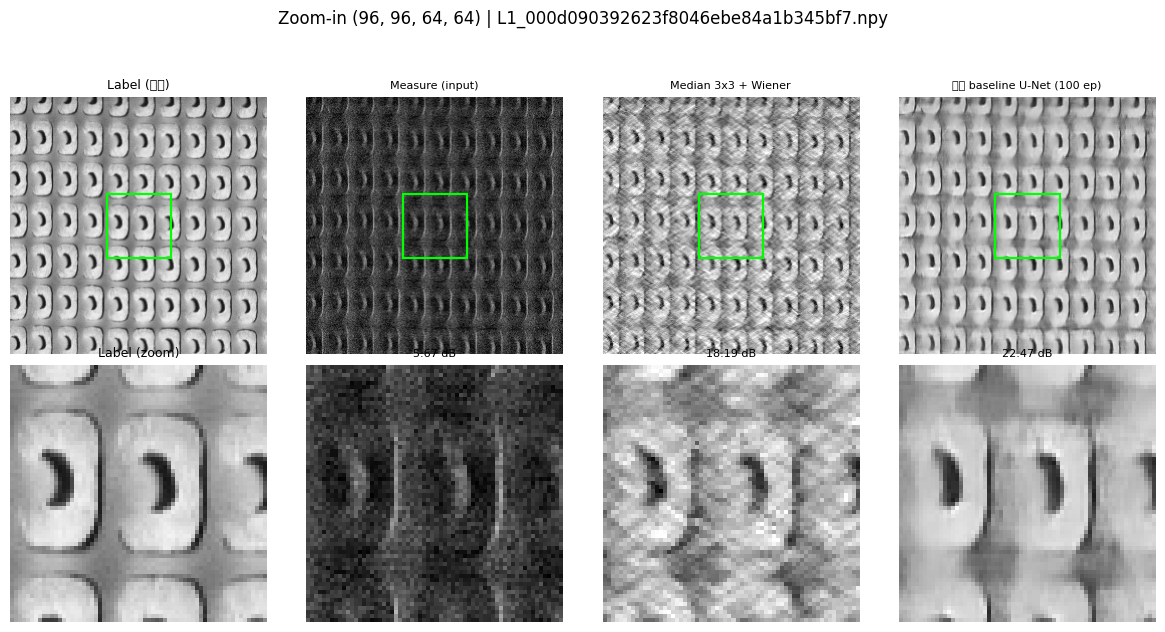

In [26]:
ZOOM = (96, 96, 64, 64)  # (row, col, h, w)
_show = [k for k in ["measure", "conv_median", "baseline_unet", "phys_unet_tta", "phys_unet"] if k in _preds][:4]

r0, c0, hh, ww = ZOOM
fig, axes = plt.subplots(2, 1 + len(_show), figsize=(3.0 * (1 + len(_show)), 6.4))
axes[0, 0].imshow(lab, cmap="gray", vmin=0, vmax=1)
axes[0, 0].add_patch(plt.Rectangle((c0, r0), ww, hh, ec="lime", fc="none", lw=1.6))
axes[0, 0].set_title("Label (전체)", fontsize=9)
axes[1, 0].imshow(lab[r0 : r0 + hh, c0 : c0 + ww], cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title("Label (zoom)", fontsize=9)
for c, key in enumerate(_show):
    img = _preds[key].cpu().numpy().squeeze()
    axes[0, c + 1].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[0, c + 1].add_patch(plt.Rectangle((c0, r0), ww, hh, ec="lime", fc="none", lw=1.6))
    axes[0, c + 1].set_title(METHOD_LABEL[key], fontsize=8)
    axes[1, c + 1].imshow(img[r0 : r0 + hh, c0 : c0 + ww], cmap="gray", vmin=0, vmax=1)
    axes[1, c + 1].set_title(f"{calculate_psnr(_preds[key], _lab_t).item():.2f} dB", fontsize=8)
for ax in axes.flatten():
    ax.axis("off")
fig.suptitle(f"Zoom-in {ZOOM} | {_name}", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

### 8-3. Error map (상대 오차율 %)

교수님 요구사항: `error_map = (I_restored − I_GT) / I_GT × 100` (%)

noise type 4종에서 각각 샘플을 골라 생성한다. 어두운 영역(`I_GT→0`)은 상대오차가 발산하므로
`I_GT < 0.05` 인 픽셀은 마스킹해 표시한다.

best method: 제공 baseline U-Net (100 ep) (baseline_unet)


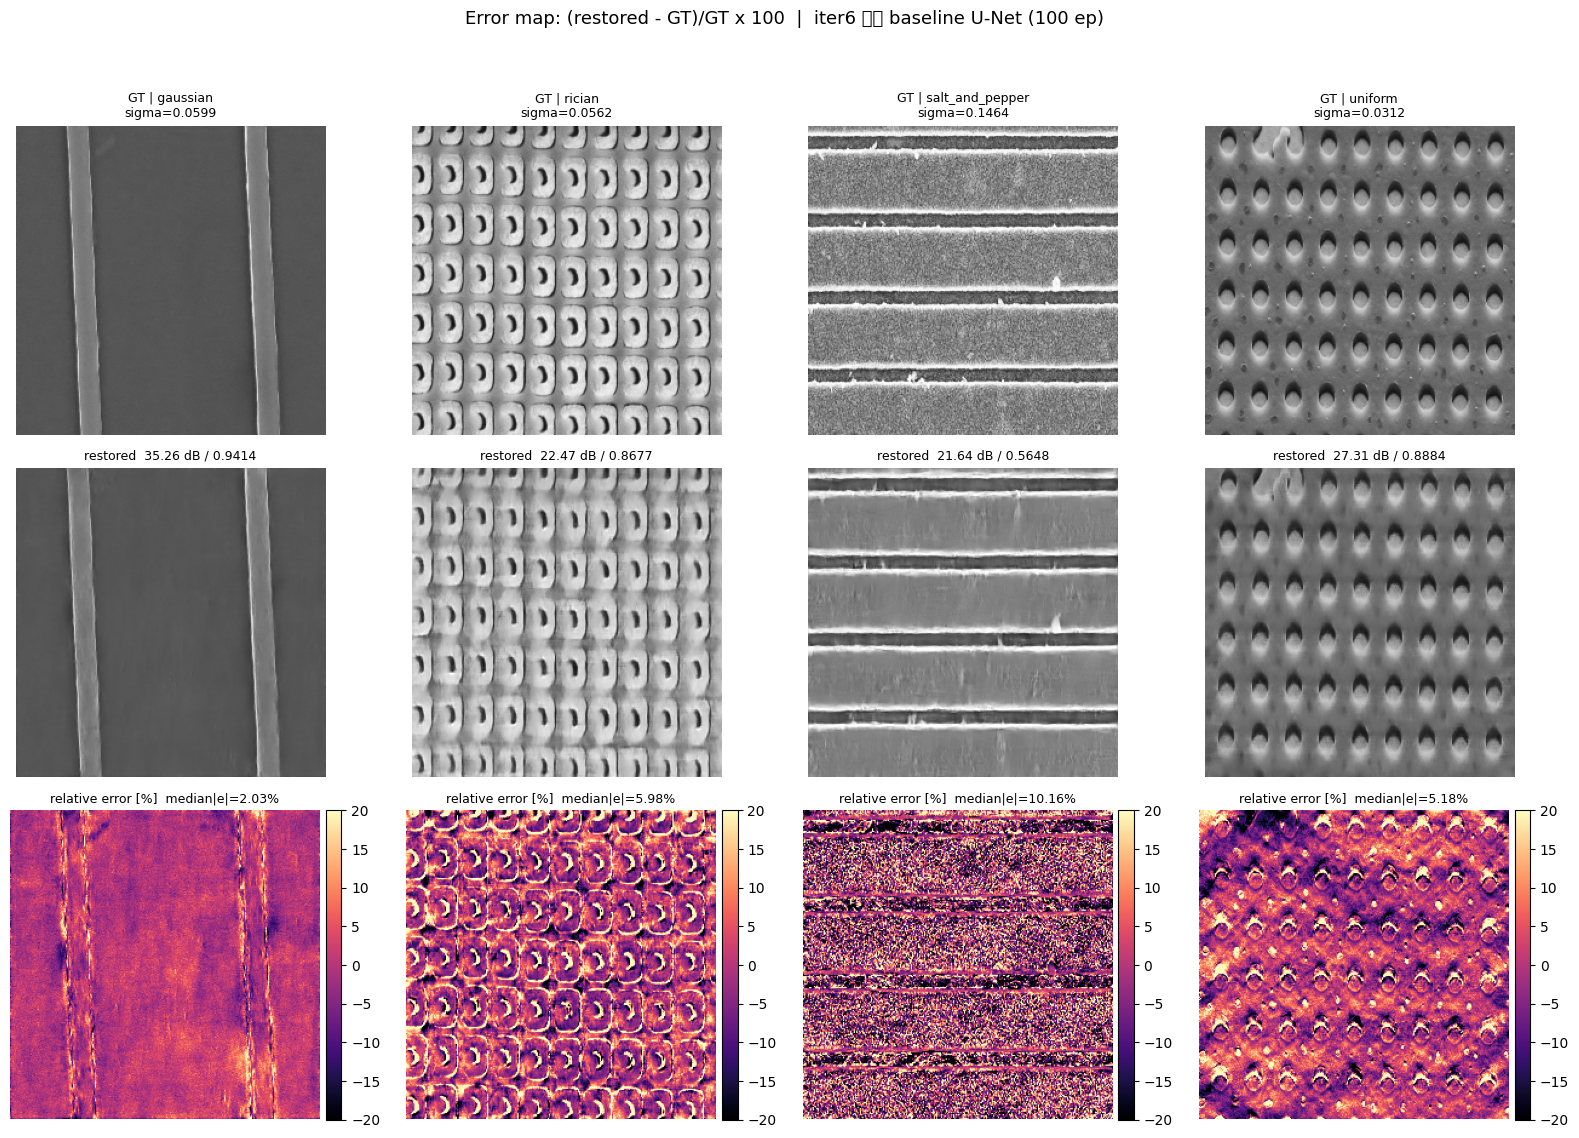

저장 완료: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/claude-final/error_maps_iter7/error_maps_baseline_unet.png


In [27]:
BEST_METHOD = max(METHODS, key=lambda k: float(np.mean([r[f"psnr_{k}"] for r in rows])))
print(f"best method: {METHOD_LABEL[BEST_METHOD]} ({BEST_METHOD})")

ERR_DIR = WORK_ROOT / "error_maps_iter7"
ERR_DIR.mkdir(parents=True, exist_ok=True)

# noise type 별 대표 샘플 1개씩
_pick: dict[str, int] = {}
for _i in range(len(test_ds)):
    _nm = test_ds.measure.names[_i]
    _t = TEST_NOISE_META.get(_nm, {}).get("noise_type")
    if _t in NOISE_NAMES and _t not in _pick:
        _pick[_t] = _i
    if len(_pick) == len(NOISE_NAMES):
        break

fig, axes = plt.subplots(3, len(_pick), figsize=(4.0 * len(_pick), 11.5))
if len(_pick) == 1:
    axes = axes[:, None]
for c, (_t, _i) in enumerate(sorted(_pick.items())):
    _lb, _me, _, _, _, _nm = test_ds[_i]
    _lb_t, _me_t = _lb[None].to(config.device), _me[None].to(config.device)
    with torch.no_grad():
        _pr = all_predict(_me_t)[BEST_METHOD]
    gt = _lb_t.cpu().numpy().squeeze()
    pr = _pr.cpu().numpy().squeeze()

    rel = (pr - gt) / (gt + 1e-6) * 100.0
    rel = np.ma.masked_where(gt < 0.05, rel)

    axes[0, c].imshow(gt, cmap="gray", vmin=0, vmax=1)
    axes[0, c].set_title(f"GT | {_t}\nsigma={TEST_NOISE_META.get(_nm, {}).get('sigma', float('nan')):.4f}", fontsize=9)
    axes[1, c].imshow(pr, cmap="gray", vmin=0, vmax=1)
    axes[1, c].set_title(f"restored  {calculate_psnr(_pr, _lb_t).item():.2f} dB / {calculate_ssim(_pr, _lb_t).item():.4f}", fontsize=9)
    im = axes[2, c].imshow(rel, cmap="magma", vmin=-20, vmax=20)
    axes[2, c].set_title(f"relative error [%]  median|e|={np.ma.median(np.abs(rel)):.2f}%", fontsize=9)
    plt.colorbar(im, ax=axes[2, c], fraction=0.046, pad=0.02)
    for r in range(3):
        axes[r, c].axis("off")

fig.suptitle(f"Error map: (restored - GT)/GT x 100  |  iter6 {METHOD_LABEL[BEST_METHOD]}", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(ERR_DIR / f"error_maps_{BEST_METHOD}.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"저장 완료: {ERR_DIR / f'error_maps_{BEST_METHOD}.png'}")


### 8-4. 취약점 분석

어떤 noise 와 어떤 영상에서 약한지 정량화한다. 발표의 "한계" 슬라이드 근거가 된다.

=== 제공 baseline U-Net (100 ep) 취약점 ===

[noise type 별]
  rician             PSNR  21.264 (입력   8.664, 개선 +12.600)  SSIM 0.7012
  uniform            PSNR  25.193 (입력   7.900, 개선 +17.293)  SSIM 0.8467
  salt_and_pepper    PSNR  26.795 (입력   7.925, 개선 +18.870)  SSIM 0.8695
  gaussian           PSNR  26.812 (입력   8.156, 개선 +18.656)  SSIM 0.8425

[하위 5장]
  L1_6ce7d8c7045dae4d27f27a9de5d2a8c  rician            sigma=0.1157  PSNR 14.262
  L1_2db776ffc20817f8e0c4b78ee9e8f38  uniform           sigma=0.1931  PSNR 16.122
  L1_2dcc564130f9019f9c508d6e85978e2  rician            sigma=0.1213  PSNR 16.761
  L1_5bead158cde10dd031880167d2c92d9  rician            sigma=0.1203  PSNR 16.964
  L1_1bd708f6dc494e81343d67e399d59b2  rician            sigma=0.0918  PSNR 17.607

[상위 5장]
  L1_02cb3d23b5d74d2875052f767acf48c  gaussian          sigma=0.0599  PSNR 35.259
  L1_46f1e070c10b19f952a8c2843517e2c  gaussian          sigma=0.0598  PSNR 34.386
  L1_96578dac7ec11475088527aaf0e32e1  salt_and_pepper   sigma=0.0

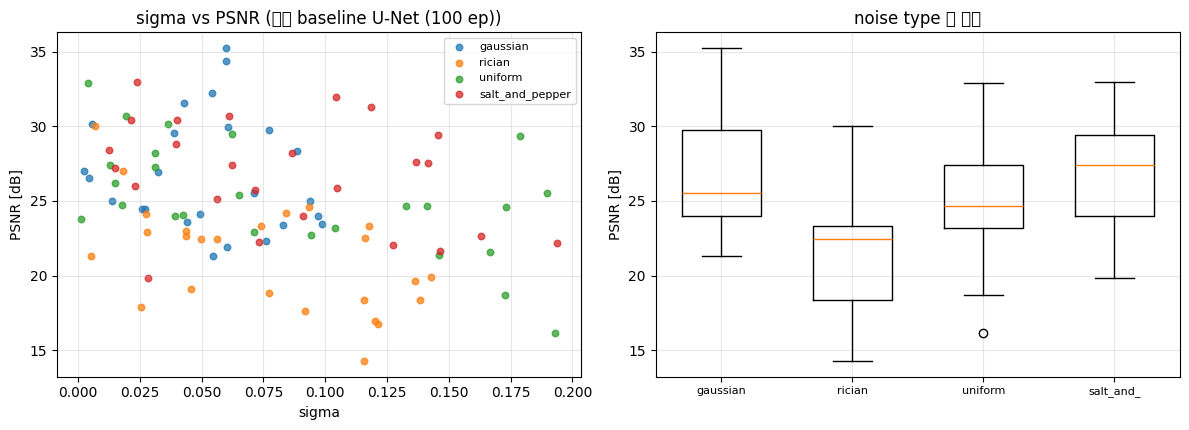

In [28]:
_key = BEST_METHOD
print(f"=== {METHOD_LABEL[_key]} 취약점 ===")
print()
print("[noise type 별]")
_by = sorted(NOISE_NAMES, key=lambda t: np.mean([r[f"psnr_{_key}"] for r in rows if r["noise_type"] == t]))
for _t in _by:
    _v = [r[f"psnr_{_key}"] for r in rows if r["noise_type"] == _t]
    _s = [r[f"ssim_{_key}"] for r in rows if r["noise_type"] == _t]
    _in = [r["psnr_measure"] for r in rows if r["noise_type"] == _t]
    print(f"  {_t:<18} PSNR {np.mean(_v):>7.3f} (입력 {np.mean(_in):>7.3f}, 개선 {np.mean(_v) - np.mean(_in):>+6.3f})  SSIM {np.mean(_s):.4f}")

print()
print("[하위 5장]")
for r in sorted(rows, key=lambda r: r[f"psnr_{_key}"])[:5]:
    _m = TEST_NOISE_META.get(r["file"], {})
    print(f"  {r['file'][:34]:<36}{r['noise_type']:<18}sigma={_m.get('sigma', float('nan')):.4f}  PSNR {r[f'psnr_{_key}']:.3f}")

print()
print("[상위 5장]")
for r in sorted(rows, key=lambda r: -r[f"psnr_{_key}"])[:5]:
    _m = TEST_NOISE_META.get(r["file"], {})
    print(f"  {r['file'][:34]:<36}{r['noise_type']:<18}sigma={_m.get('sigma', float('nan')):.4f}  PSNR {r[f'psnr_{_key}']:.3f}")

# sigma 와 PSNR 의 관계
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for _t in NOISE_NAMES:
    _x = [TEST_NOISE_META.get(r["file"], {}).get("sigma", np.nan) for r in rows if r["noise_type"] == _t]
    _y = [r[f"psnr_{_key}"] for r in rows if r["noise_type"] == _t]
    axes[0].scatter(_x, _y, s=22, alpha=0.75, label=_t)
axes[0].set_xlabel("sigma")
axes[0].set_ylabel("PSNR [dB]")
axes[0].set_title(f"sigma vs PSNR ({METHOD_LABEL[_key]})")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

_pos = np.arange(len(NOISE_NAMES))
axes[1].boxplot([[r[f"psnr_{_key}"] for r in rows if r["noise_type"] == t] for t in NOISE_NAMES], positions=_pos, widths=0.6)
axes[1].set_xticks(_pos)
axes[1].set_xticklabels([t[:9] for t in NOISE_NAMES], fontsize=8)
axes[1].set_ylabel("PSNR [dB]")
axes[1].set_title("noise type 별 분포")
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 9. 학습 곡선 & 요약

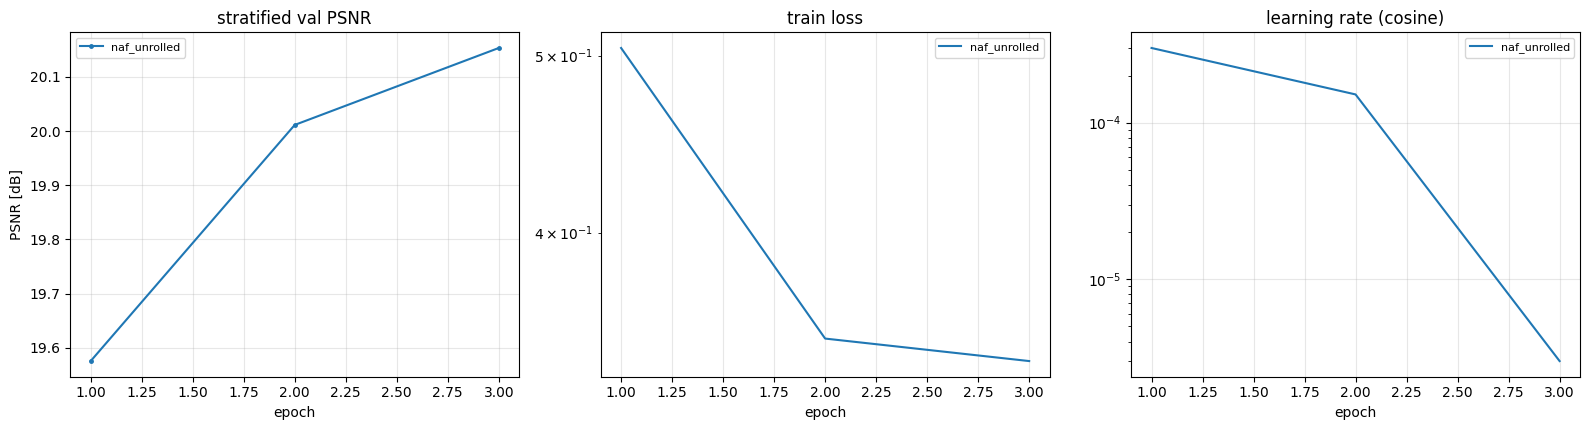


run                 params  best ep   val PSNR  test PSNR  test SSIM
--------------------------------------------------------------------
naf_unrolled     2,378,410        3     20.153     20.170     0.6110


In [29]:
if RESULTS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
    for _k, _r in RESULTS.items():
        _h = [x for x in _r["history"] if "val_psnr" in x]
        if not _h:
            continue
        _ep = [x["epoch"] for x in _h]
        axes[0].plot(_ep, [x["val_psnr"] for x in _h], marker="o", ms=2.5, label=_k)
        axes[1].plot([x["epoch"] for x in _r["history"]], [x["train_loss"] for x in _r["history"]], label=_k)
        axes[2].plot([x["epoch"] for x in _r["history"]], [x["lr"] for x in _r["history"]], label=_k)
    axes[0].set_title("stratified val PSNR")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("PSNR [dB]")
    axes[1].set_title("train loss")
    axes[1].set_xlabel("epoch")
    axes[1].set_yscale("log")
    axes[2].set_title("learning rate (cosine)")
    axes[2].set_xlabel("epoch")
    axes[2].set_yscale("log")
    for a in axes:
        a.grid(alpha=0.3)
        a.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

    print()
    print(f"{'run':<14}{'params':>12}{'best ep':>9}{'val PSNR':>11}{'test PSNR':>11}{'test SSIM':>11}")
    print("-" * 68)
    for _k, _r in RESULTS.items():
        _tp = np.mean([r[f"psnr_{_k}"] for r in rows]) if f"psnr_{_k}" in rows[0] else float("nan")
        _ts = np.mean([r[f"ssim_{_k}"] for r in rows]) if f"ssim_{_k}" in rows[0] else float("nan")
        print(f"{_k:<14}{_r['params']:>12,}{_r['best']['epoch']:>9}{_r['best']['psnr']:>11.3f}{_tp:>11.3f}{_ts:>11.4f}")
else:
    print("학습된 모델이 없다. 7-1 셀을 실행할 것.")

In [30]:
summary = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "experiment": "iter6_unrolled_physics_network",
    "config": {k: str(v) for k, v in asdict(config).items()},
    "best_wiener_K": BEST_K,
    "test": {
        k: {
            "psnr": round(float(np.mean([r[f"psnr_{k}"] for r in rows])), 3),
            "ssim": round(float(np.mean([r[f"ssim_{k}"] for r in rows])), 4),
            "per_noise_psnr": {
                t: round(float(np.mean([r[f"psnr_{k}"] for r in rows if r["noise_type"] == t])), 3)
                for t in NOISE_NAMES
                if any(r["noise_type"] == t for r in rows)
            },
        }
        for k in METHODS
    },
    "runs": {
        k: {"run_dir": str(v["run_dir"]), "best": v["best"], "params": v["params"], "spec": v["spec"]}
        for k, v in RESULTS.items()
    },
}
_out = WORK_ROOT / "summary_iter7.json"
_out.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"저장 완료: {_out}")
print()
print(json.dumps(summary["test"], indent=2, ensure_ascii=False))


저장 완료: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/claude-final/summary_iter7.json

{
  "measure": {
    "psnr": 8.161,
    "ssim": -0.0143,
    "per_noise_psnr": {
      "gaussian": 8.156,
      "rician": 8.664,
      "uniform": 7.9,
      "salt_and_pepper": 7.925
    }
  },
  "conv_none": {
    "psnr": 15.228,
    "ssim": 0.4146,
    "per_noise_psnr": {
      "gaussian": 15.778,
      "rician": 13.676,
      "uniform": 16.181,
      "salt_and_pepper": 15.276
    }
  },
  "conv_mean": {
    "psnr": 19.256,
    "ssim": 0.5296,
    "per_noise_psnr": {
      "gaussian": 20.393,
      "rician": 16.023,
      "uniform": 20.454,
      "salt_and_pepper": 20.153
    }
  },
  "conv_median": {
    "psnr": 19.288,
    "ssim": 0.5453,
    "per_noise_psnr": {
      "gaussian": 19.485,
      "rician": 15.535,
      "uniform": 18.88,
      "salt_and_pepper": 23.252
    }
  },
  "conv_adaptive": {
    "psnr": 19.088,
    "ssim": 0.5512,
    "per_noise_psnr": {
      "gaussian": 20.519,
      "

## 10. 다음 단계

이 노트북으로 얻은 수치를 보고 판단할 것.

| 우선순위 | 항목 | 근거 |
|---|---|---|
| 1 | **C(phys_unet)가 conventional 을 못 넘으면** `phys_scale` 을 키우고 `dc_weight` 를 줄인다 | zero-init residual 이 학습되지 않은 것 |
| 2 | **Rician 이 최하위면** variance-stabilizing transform 또는 bias 보정항 | `E[\|s+n\|] > s`, 신호 0 영역에서 `σ√(π/2)` bias |
| 3 | **S&P 가 최하위면** median prefilter 를 모델 입력 채널에 추가 | impulse 는 detection 문제라 국소 median 이 강함 |
| 4 | σ 조건부 입력 (FFDNet 방식) | 저노이즈 구간에서 상대 이득이 작은 문제 |
| 5 | Label-free (Noise2Noise) | 가산점. `variant_pool` 의 같은 noise type 두 실현을 pair 로 쓰면 된다 |
| 6 | Unrolled / physics DC step | 조교 `model_config` 에 `unroll_iters`, `phys_dc_steps` 흔적이 있다 |

**발표 자료용으로 이미 확보되는 것**
- 전체 파이프라인 구조 (2절 forward model + 6절 모델 표)
- 복원 전/후 비교 (8-1) + zoom-in (8-2)
- error map (8-3)
- conventional 대비 정량 비교 (8절 표)
- 취약점 분석 (8-4)
- 방법론 선택 근거 (6절 C 를 넣는 이유 — iter1 의 실패 수치를 근거로 제시)